
<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_05_reg_multivariada_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 5: Regresión multivariada

In [ ]:
import numpy as np
import matplotlib.pylab as plt
import pandas as pd
import plotly.graph_objects as go



Supongamos que tenemos un conjunto de caracteristicas $X = X_1,X_2...X_j...X_n$ para realizar una  predicción $y$ con valores esperados $\hat{y}$.  

Cada X, puede ser escrito como:
 $X_1 = x_1^{(1)},x_1^{(2)}, x_1^{(3)}...x_1^{(m)}$,

 $X_2 = x_2^{(1)},x_2^{(2)}, x_2^{(3)}...x_2^{(m)}$,

 .

 .

 .

 $X_n = x_n^{(1)},x_n^{(2)}, x_n^{(3)}...x_n^{(m)}$.


Siendo n el número de caracteristicas y m el número de datos de datos,
$\hat{y} = \hat{y}_1^{(1)}, \hat{y}_1^{(2)}...\hat{y}_1^{(m)} $, el conjunto de datos etiquetados  y $y = y_1^{(1)}, y_1^{(2)}...y_1^{(m)} $ los valores predichos por un modelo




Lo anterior puede ser resumido  como:



|Training|$\hat{y}$      | X_1  | X_2  |  .  | .|. |. | X_n|
|--------|-------|------|------|-----|--|--|--|----|
|1|$\hat{y}_1^{1}$ | $x_1^{1}$|$x_2^{1}$| .  | .|. |. | $x_n^{1}$|
|2|$\hat{y}_1^{2}$ | $x_1^{2}$|$x_2^{2}$| .  | .|. |. | $x_n^{2}$|
|.|.         | .        |.| .  | .|. |. | |
|.|.         | .        |.| .  | .|. |. | |
|.|.         | .        |.| .  | .|. |. | |
|m|$\hat{y}_1^{m}$ | $x_1^{m}$  |$x_2^{m}$| .  | .|. |. | $x_n^{m}$|


y el el modelo puede ser ajustado como sigue:

Para un solo conjunto de datos de entrenamiento tentemos que:

$y = h(\theta_0,\theta_1,\theta_2,...,\theta_n ) = \theta_0 + \theta_1 x_1+\theta_2 x_2 + \theta_3 x_3 +...+ \theta_n x_n $.


$h_{\Theta}(x)$ = $[\theta_0,\theta_1,...,\theta_n ]$
\begin{bmatrix}
1\\
x_1\\
x_2\\
.\\
.\\
.\\
x_n\\
\end{bmatrix} = $\Theta^T X$




Para todo el conjunto de datos, tenemos que:

Sea $\Theta^T = [\theta_0,\theta_1,\theta_2,...,\theta_n]$ una matrix $1 \times (n+1)$ y  


\begin{equation}
X =
\begin{bmatrix}
1& 1 & 1 & .&.&.&1\\
x_1^{(1)}&x_2^{(1)} & x_3^{(1)} & .&.&.&x_m^{1}\\
.&. & . &.&.&.& .\\
.&. & . & .&.&.&.\\
.&. & . & .&.&.&.\\
x_1^{(n+1)}&x_2^{(n+1)} & x_3^{(n+1)} & .&.&.&x_m^{(n+1)}\\
\end{bmatrix}_{(n+1) \times m}
\end{equation}




luego $h = \Theta^{T} X $ con dimension $1\times m$




La anterior ecuación, es un hiperplano en $\mathbb{R}^n$. Notese que en caso de tener una sola característica, la ecuación puede ser análizada según lo visto en la sesión de regresion lineal.


Para la optimización, vamos a definir la función de coste **$J(\theta_1,\theta_2,\theta_3, ...,\theta_n )$** , como la función  asociada a la minima distancia entre dos puntos, según la metrica euclidiana.

- Metrica Eculidiana

\begin{equation}
J(\theta_1,\theta_2,\theta_3, ...,\theta_n )=\frac{1}{2m} \sum_{i=1}^m ( h_{\Theta} (X)-\hat{y}^{(i)})^2 =\frac{1}{2m} \sum_{i = 1}^m (\Theta^{T} X - \hat{y}^{(i)})^2
\end{equation}

Otras métricas pueden ser definidas como sigue en la siguiente referencia.  [Metricas](https://jmlb.github.io/flashcards/2018/04/21/list_cost_functions_fo_neuralnets/).

Nuestro objetivo será encontrar los valores mínimos
$\Theta = \theta_0,\theta_1,\theta_2,...,\theta_n$ que minimizan el error, respecto a los valores etiquetados y esperados $\hat{y}$


Para encontrar $\Theta$ optimo, se necesita  minimizar la función de coste, que permite obtener los valores más cercanos,  esta minimización podrá ser realizada a través de diferentes metodos, el más conocido es el gradiente descendente.








## Gradiente descendente

Consideremos la función de coste sin realizar el promedio  de funcion de coste:
\begin{equation}
\Lambda^T =
\begin{bmatrix}
(\theta_0 1 + \theta_1 x_1^1+\theta_2 x_2^2 + \theta_3 x_3^3 +...+ \theta_n x_n^n - \hat{y}^{1})^2 \\
(\theta_0 1+ \theta_1 x_1^1+\theta_2 x_2^2 + \theta_3 x_3^3 +...+ \theta_n x_n^n - \hat{y}^{2})^2\\
.\\
.\\
.\\
(\theta_0 1 + \theta_1 x_1^m+\theta_2 x_2^m + \theta_3 x_3^m +...+ \theta_n x_n^m - \hat{y}^{m})^2\\
\end{bmatrix}
\end{equation}

$\Lambda= [\Lambda_1,\Lambda_2, ...,\Lambda_m]$

$J = \frac{1}{2m} \sum_{i}^m \Lambda_i $

El gradiente descente, puede ser escrito como:

\begin{equation}
\Delta \vec{\Theta} =  - \alpha \nabla J(\theta_0, \theta_1,...,\theta_n)
\end{equation}

escogiendo el valor j-esimo tenemos que:

\begin{equation}
\theta_j :=  - \alpha \frac{\partial J(\theta_0, \theta_1,...\theta_j...,\theta_n)}{\partial \theta_j}
\end{equation}

Aplicando lo anterior a a función de coste asociada a la métrica ecuclidiana, tenemos que:

Para $j = 0$,


\begin{equation}
\theta_0 :=  - \alpha \frac{\partial J(\theta_0, \theta_1,...\theta_j...,\theta_n)}{\partial \theta_0} = \frac{1}{m}\alpha \sum_{i=1}^m (\theta_j X_{ji} - \hat{y}^{(i)}) 1
\end{equation}



Para $0<j<n $

\begin{equation}
\theta_j :=  - \alpha \frac{\partial J(\theta_0, \theta_1,...\theta_j...,\theta_n)}{\partial \theta_j} = \frac{1}{m} \alpha\sum_{i=1}^m (\theta_{j} X_{ji} - \hat{y}^{(i)}) X_j
\end{equation}

donde X_j es el vector de entrenamiento j-esimo.

Lo  anterior puede ser generalizado como siguem, teniendo presente que $X_0 = \vec{1}$


Para $0\leq j<n$,

\begin{equation}
\theta_j :=  - \alpha \frac{\partial J(\theta_0, \theta_1,...\theta_j...,\theta_n)}{\partial \theta_j} = \frac{1}{m} \alpha\sum_{i=1}^m (\theta_j X_{ji} - \hat{y}^{(i)}) X_j
\end{equation}



# Vectorizando el grandiente descendete, tenemos que:
\begin{equation}
\nabla J = \Lambda^T X
\end{equation}

Luego:

\begin{equation}
\Theta=\Theta-\alpha \nabla J
\end{equation}



1. Para simular un conjunto de características $x_1$ , $x_2$,..., $x_n$ trabajaremos en la primera parte con dos características de datos aleatorios que presentan un plano y mostraremos que los párametros optimizados se corresponden con el valor esperado.

- Definir la ecuación  $y = 2.1*x_1 - 3.1*x_2$, y generar números aleatorios que pertenecen al plano.

- Realizar un diagrama 3D de los puntos generados aleatoriamente.


Nuestro objetivo será encontrar los valores $\theta_0 = 0, \theta_1=2.1, \theta_1=3.1$ que mejor ajustar el plano, empleando cálculos vectorizados.

2. Inicializar conjunto de parámetros $\Theta$ de manera aleatoria.
3. Construir la matrix X con dimensiones $(n+1, m)$, m es el numero de datos de entrenamiento y (n) el número de caracteristicas.
4. Calcular la función de coste(revise cuidosamente las dimensiones de cada matriz):

  - $h = \Theta^{T} X $
  - $\Lambda= (h -Y) $
  - $\Lambda*= (h -Y)^2 $
  - $\Lambda= [\Lambda_1,\Lambda_2, ...,\Lambda_m]$
  - $J = \frac{1}{2m} \sum_{i}^m \Lambda_i $

5. Aplicar el gradiente descendente:
  - Encontrar el gradiente.
    $\nabla J = \Lambda X.T$
  
  - Actualizar los nuevos parametros:
    $\Theta_{n+1}=\Theta_{n}-\alpha\nabla J$


6. Iterar para encontrar los valores $\Theta$ que se ajustan el plano.








7. Reescribir su código como una clase (ver ayuda)

Dimensiones de X: (3, 100)
Dimensiones de Y: (1, 100)
Número de características (incluyendo sesgo): 3
Número de ejemplos de entrenamiento: 100

=== Inicializando modelo ===
Parámetros iniciales: [0.64203165 0.08413996 0.16162871]

=== Entrenando modelo ===
Iteración 20/500, Costo: 0.657236
Iteración 40/500, Costo: 0.155083
Iteración 60/500, Costo: 0.036942
Iteración 80/500, Costo: 0.008819
Iteración 100/500, Costo: 0.002109
Iteración 120/500, Costo: 0.000505
Iteración 140/500, Costo: 0.000121
Iteración 160/500, Costo: 0.000029
Iteración 180/500, Costo: 0.000007
Iteración 200/500, Costo: 0.000002
Iteración 220/500, Costo: 0.000000
Iteración 240/500, Costo: 0.000000
Iteración 260/500, Costo: 0.000000
Iteración 280/500, Costo: 0.000000
Iteración 300/500, Costo: 0.000000
Iteración 320/500, Costo: 0.000000
Iteración 340/500, Costo: 0.000000
Iteración 360/500, Costo: 0.000000
Iteración 380/500, Costo: 0.000000
Iteración 400/500, Costo: 0.000000
Iteración 420/500, Costo: 0.000000
Iteración 44

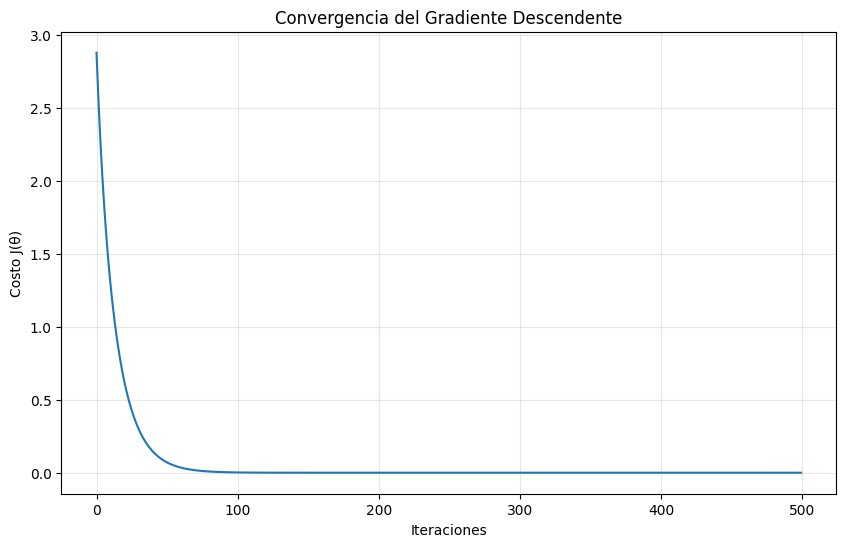


=== Validación del modelo ===
R² score en datos de prueba: 1.000000
Error cuadrático medio (MSE): 0.000000


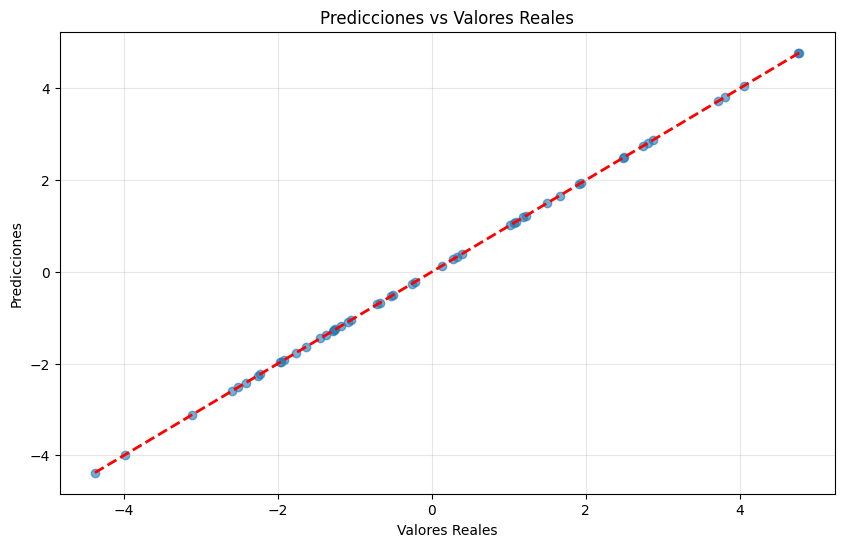


=== Información del modelo ===
Ecuación aprendida: y = 0.000000 + 2.100000·x₁ + -3.100000·x₂
Ecuación original:   y = 0.000000 + 2.100000·x₁ - 3.100000·x₂
Precisión del modelo: 100.00%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go

# ============================================
# PARTE 1: Simulación de datos y visualización
# ============================================

# 1. Definir la ecuación y generar puntos aleatorios
N = 100  # Número de puntos aleatorios

# Generar puntos aleatorios en el rango [-1, 1] para x1 y x2
np.random.seed(42)  # Para reproducibilidad
x1_rand = np.random.uniform(-1, 1, N)
x2_rand = np.random.uniform(-1, 1, N)

# Calcular y según la ecuación del plano: y = 2.1*x1 - 3.1*x2
y_rand = 2.1 * x1_rand - 3.1 * x2_rand

# Crear figura con los puntos aleatorios en el plano
fig_puntos = go.Figure()

# Añadir los puntos aleatorios
fig_puntos.add_trace(go.Scatter3d(
    x=x1_rand,
    y=x2_rand,
    z=y_rand,
    mode='markers',
    marker=dict(size=5, color='blue', opacity=0.8),
    name='Puntos en el plano'
))

# Añadir el plano para referencia
x1_grid = np.linspace(-1, 1, 20)
x2_grid = np.linspace(-1, 1, 20)
X1_grid, X2_grid = np.meshgrid(x1_grid, x2_grid)
Y_grid = 2.1 * X1_grid - 3.1 * X2_grid

fig_puntos.add_trace(go.Surface(
    x=X1_grid,
    y=X2_grid,
    z=Y_grid,
    colorscale='Viridis',
    opacity=0.3,
    name='Plano original'
))

fig_puntos.update_layout(
    title='Puntos aleatorios en el plano y = 2.1*x₁ - 3.1*x₂',
    scene=dict(
        xaxis_title='x₁',
        yaxis_title='x₂',
        zaxis_title='y'
    )
)

fig_puntos.show()

# ============================================
# PARTE 2: Regresión Multilineal
# ============================================

# Preparar los datos para la regresión
df = pd.DataFrame({"x1": x1_rand, "x2": x2_rand, "y": y_rand})
df["ones"] = 1  # Columna para el término de sesgo (θ₀)

# Construir matriz X (dimensiones: (n+1, m)) e Y (dimensiones: (1, m))
X = df[["ones", "x1", "x2"]].values.T  # Shape: (3, N)
Y = df.y.values.reshape(1, N)  # Shape: (1, N)

Nfeatures = np.shape(X)[0]  # n+1 = 3
m = np.shape(X)[1]  # N = 100

print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de Y: {Y.shape}")
print(f"Número de características (incluyendo sesgo): {Nfeatures}")
print(f"Número de ejemplos de entrenamiento: {m}")

# ============================================
# CLASE DE REGRESIÓN MULTILINEAL
# ============================================

class MultilinearRegression:
    """
    Clase para regresión multilineal usando gradiente descendente
    """
    def __init__(self, X, Y):
        """
        Inicializa el modelo de regresión multilineal

        Parámetros:
        X: matriz de características con dimensiones (n+1, m)
        Y: vector de etiquetas con dimensiones (1, m)
        """
        self.X = X
        self.Y = Y
        self.Nfeatures = X.shape[0]  # n+1
        self.m = X.shape[1]  # número de ejemplos

        # 2. Inicializar parámetros Θ de manera aleatoria
        self.theta = np.random.random(self.Nfeatures).reshape(self.Nfeatures, 1)
        self.h = None
        self.J = None

    def model(self):
        """
        Calcula la hipótesis h = ΘᵀX

        Returns:
        h: predicciones del modelo con dimensiones (1, m)
        """
        # 4. Calcular h = ΘᵀX
        self.h = self.theta.T @ self.X  # Shape: (1, m)
        return self.h

    def costo(self):
        """
        Calcula la función de costo J = (1/(2m)) * Σ(h - Y)²

        Returns:
        J: valor del costo
        """
        # 4. Calcular Λ = (h - Y)
        Lambda = self.h - self.Y  # Shape: (1, m)

        # Calcular Λ* = (h - Y)²
        Lambda_cuadrado = Lambda ** 2  # Shape: (1, m)

        # Calcular J = (1/(2m)) * ΣΛ_i
        self.J = (1/(2 * self.m)) * np.sum(Lambda_cuadrado)
        return self.J

    def update_params(self, learning_rate):
        """
        Actualiza los parámetros usando gradiente descendente

        Parámetros:
        learning_rate: tasa de aprendizaje α

        Returns:
        theta: parámetros actualizados
        """
        # 5. Calcular Λ = (h - Y)
        Lambda = self.h - self.Y  # Shape: (1, m)

        # Calcular el gradiente: ∇J = (1/m) * (Λ @ Xᵀ)ᵀ
        grad = (1/self.m) * (Lambda @ self.X.T).T  # Shape: (3, 1)

        # 5. Actualizar parámetros: Θ = Θ - α∇J
        self.theta = self.theta - learning_rate * grad
        return self.theta

    def fit(self, learning_rate=0.01, n_iterations=100, verbose=True):
        """
        Entrena el modelo usando gradiente descendente

        Parámetros:
        learning_rate: tasa de aprendizaje α
        n_iterations: número de iteraciones
        verbose: si es True, muestra el progreso

        Returns:
        J_history: historial del costo durante el entrenamiento
        """
        J_history = np.zeros(n_iterations)

        for i in range(n_iterations):
            # 6. Iterar para encontrar los Θ óptimos
            self.model()  # Calcular h
            self.costo()  # Calcular J
            J_history[i] = self.J
            self.update_params(learning_rate)  # Actualizar parámetros

            if verbose and (i + 1) % 20 == 0:
                print(f"Iteración {i+1}/{n_iterations}, Costo: {self.J:.6f}")

        return J_history

    def predict(self, X_new):
        """
        Realiza predicciones con nuevos datos

        Parámetros:
        X_new: matriz de nuevas características (n+1, m_new)

        Returns:
        predicciones: valores predichos (1, m_new)
        """
        return self.theta.T @ X_new

    def get_parameters(self):
        """
        Retorna los parámetros aprendidos

        Returns:
        theta: vector de parámetros (θ₀, θ₁, θ₂, ..., θₙ)
        """
        return self.theta.flatten()

    def get_cost(self):
        """
        Retorna el último costo calculado
        """
        return self.J

    def score(self, X_test, Y_test):
        """
        Calcula el R² score del modelo

        Parámetros:
        X_test: matriz de características de prueba (n+1, m_test)
        Y_test: valores reales de prueba (1, m_test)

        Returns:
        r2: coeficiente de determinación R²
        """
        Y_pred = self.predict(X_test)

        # Calcular R² = 1 - (SS_res / SS_tot)
        ss_res = np.sum((Y_test - Y_pred) ** 2)
        ss_tot = np.sum((Y_test - np.mean(Y_test)) ** 2)
        r2 = 1 - (ss_res / ss_tot)

        return r2

# ============================================
# PARTE 3: Entrenamiento y evaluación
# ============================================

# Crear y entrenar el modelo
print("\n=== Inicializando modelo ===")
model = MultilinearRegression(X, Y)
print(f"Parámetros iniciales: {model.get_parameters()}")

print("\n=== Entrenando modelo ===")
J_history = model.fit(learning_rate=0.1, n_iterations=500, verbose=True)

# Mostrar resultados finales
print("\n=== Resultados finales ===")
theta_final = model.get_parameters()
print(f"Parámetros aprendidos: θ₀ = {theta_final[0]:.6f}, θ₁ = {theta_final[1]:.6f}, θ₂ = {theta_final[2]:.6f}")
print(f"Parámetros esperados:  θ₀ = 0.000000, θ₁ = 2.100000, θ₂ = -3.100000")
print(f"Costo final: {model.get_cost():.6f}")

# Calcular error relativo
error_relativo_theta1 = abs((theta_final[1] - 2.1) / 2.1) * 100
error_relativo_theta2 = abs((theta_final[2] - (-3.1)) / 3.1) * 100
print(f"\nError relativo θ₁: {error_relativo_theta1:.4f}%")
print(f"Error relativo θ₂: {error_relativo_theta2:.4f}%")

# Graficar la convergencia del costo
plt.figure(figsize=(10, 6))
plt.plot(J_history)
plt.xlabel('Iteraciones')
plt.ylabel('Costo J(θ)')
plt.title('Convergencia del Gradiente Descendente')
plt.grid(True, alpha=0.3)
plt.show()

# ============================================
# PARTE 4: Validación con datos de prueba
# ============================================

# Generar datos de prueba
print("\n=== Validación del modelo ===")
N_test = 50
x1_test = np.random.uniform(-1, 1, N_test)
x2_test = np.random.uniform(-1, 1, N_test)
y_test = 2.1 * x1_test - 3.1 * x2_test

# Preparar matriz X_test
df_test = pd.DataFrame({"x1": x1_test, "x2": x2_test})
df_test["ones"] = 1
X_test = df_test[["ones", "x1", "x2"]].values.T
Y_test = y_test.reshape(1, N_test)

# Realizar predicciones
predicciones = model.predict(X_test)

# Calcular R² score
r2_score = model.score(X_test, Y_test)
print(f"R² score en datos de prueba: {r2_score:.6f}")

# Calcular error cuadrático medio (MSE)
mse = np.mean((Y_test - predicciones) ** 2)
print(f"Error cuadrático medio (MSE): {mse:.6f}")

# Visualizar predicciones vs valores reales
plt.figure(figsize=(10, 6))
plt.scatter(Y_test.flatten(), predicciones.flatten(), alpha=0.6)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores Reales')
plt.grid(True, alpha=0.3)
plt.show()

# ============================================
# PARTE 5: Visualización 3D del modelo aprendido
# ============================================

# Crear malla para visualizar el plano aprendido
x1_vis = np.linspace(-1, 1, 30)
x2_vis = np.linspace(-1, 1, 30)
X1_vis, X2_vis = np.meshgrid(x1_vis, x2_vis)

# Preparar datos para predicción
X_vis = np.array([np.ones(X1_vis.size), X1_vis.flatten(), X2_vis.flatten()])
Y_pred_vis = model.predict(X_vis).reshape(X1_vis.shape)

# Visualización comparativa
fig_comparacion = go.Figure()

# Plano original
fig_comparacion.add_trace(go.Surface(
    x=X1_grid,
    y=X2_grid,
    z=Y_grid,
    colorscale='Blues',
    opacity=0.5,
    name='Plano original (2.1x₁ - 3.1x₂)',
    showscale=False
))

# Plano aprendido
fig_comparacion.add_trace(go.Surface(
    x=X1_vis,
    y=X2_vis,
    z=Y_pred_vis,
    colorscale='Reds',
    opacity=0.5,
    name='Plano aprendido por el modelo',
    showscale=False
))

# Puntos de entrenamiento
fig_comparacion.add_trace(go.Scatter3d(
    x=x1_rand,
    y=x2_rand,
    z=y_rand,
    mode='markers',
    marker=dict(size=3, color='green', opacity=0.7),
    name='Datos de entrenamiento'
))

fig_comparacion.update_layout(
    title='Comparación: Plano original (azul) vs Plano aprendido (rojo)',
    scene=dict(
        xaxis_title='x₁',
        yaxis_title='x₂',
        zaxis_title='y'
    )
)

fig_comparacion.show()

# ============================================
# Información adicional del modelo
# ============================================
print("\n=== Información del modelo ===")
print(f"Ecuación aprendida: y = {theta_final[0]:.6f} + {theta_final[1]:.6f}·x₁ + {theta_final[2]:.6f}·x₂")
print(f"Ecuación original:   y = 0.000000 + 2.100000·x₁ - 3.100000·x₂")
print(f"Precisión del modelo: {100 - max(error_relativo_theta1, error_relativo_theta2):.2f}%")

PUNTO 1: Simulación de datos
Se generaron 100 puntos aleatorios en el plano
Ecuación del plano: y = 2.1·x₁ - 3.1·x₂
Rango de x₁: [-0.989, 0.974]
Rango de x₂: [-0.986, 0.971]
Rango de y: [-4.455, 4.074]



PUNTO 2: Inicialización de parámetros Θ
Matriz X de dimensiones: (3, 100)
Vector Y de dimensiones: (1, 100)
Parámetros Θ iniciales (aleatorios):
  θ₀ = 0.696469
  θ₁ = 0.286139
  θ₂ = 0.226851

PUNTO 3: Verificación de dimensiones de X
Dimensiones de X: (3, 100)
  - Filas (n+1): 3 = 2+1 (sesgo + 2 características)
  - Columnas (m): 100 = 100 datos de entrenamiento

Primeras 5 columnas de X:
   ones (θ₀)        x₁        x₂
0        1.0 -0.250920 -0.937142
1        1.0  0.901429  0.272821
2        1.0  0.463988 -0.371288
3        1.0  0.197317  0.017141
4        1.0 -0.687963  0.815133

PUNTO 4: Cálculo de la función de costo
Dimensiones de h (hipótesis): (1, 100)
Dimensiones de Λ (error): (1, 100)
Dimensiones de Λ* (error²): (1, 100)

Costo inicial J(Θ) = 2.842427

Primeros 5 errores (h - Y):
  Ejemplo 1: h=0.4121, Y=2.3782, error=-1.9661
  Ejemplo 2: h=1.0163, Y=1.0473, error=-0.0310
  Ejemplo 3: h=0.7450, Y=2.1254, error=-1.3804
  Ejemplo 4: h=0.7568, Y=0.3612, error=0.3956
  Ejempl

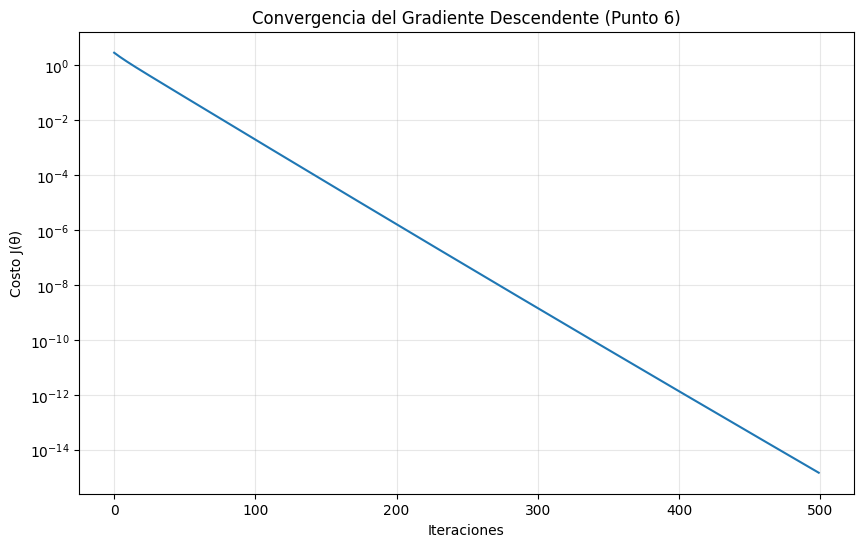


PUNTO 7: Implementación como clase

DEMOSTRACIÓN DE LA CLASE MultilinearRegression
✅ Modelo creado exitosamente

Parámetros iniciales (aleatorios):
{'theta0': np.float64(0.3745401188473625), 'theta1': np.float64(0.9507143064099162), 'theta2': np.float64(0.7319939418114051)}

Iniciando entrenamiento:
  Iteraciones: 500
  Tasa de aprendizaje: 0.1
--------------------------------------------------
  Iteración 100: Costo = 0.00258985, θ₁ = 2.081981, θ₂ = -2.982898
  Iteración 200: Costo = 0.00000242, θ₁ = 2.099908, θ₂ = -3.096365
  Iteración 300: Costo = 0.00000000, θ₁ = 2.100011, θ₂ = -3.099885
  Iteración 400: Costo = 0.00000000, θ₁ = 2.100001, θ₂ = -3.099996
  Iteración 500: Costo = 0.00000000, θ₁ = 2.100000, θ₂ = -3.100000
--------------------------------------------------
✅ Entrenamiento completado

RESUMEN DEL MODELO
Número de características (incluyendo sesgo): 3
Número de ejemplos de entrenamiento: 100

Parámetros aprendidos:
  θ₀ (sesgo) = 0.00000000
  θ₁ (coef x₁) = 2.10000003
 

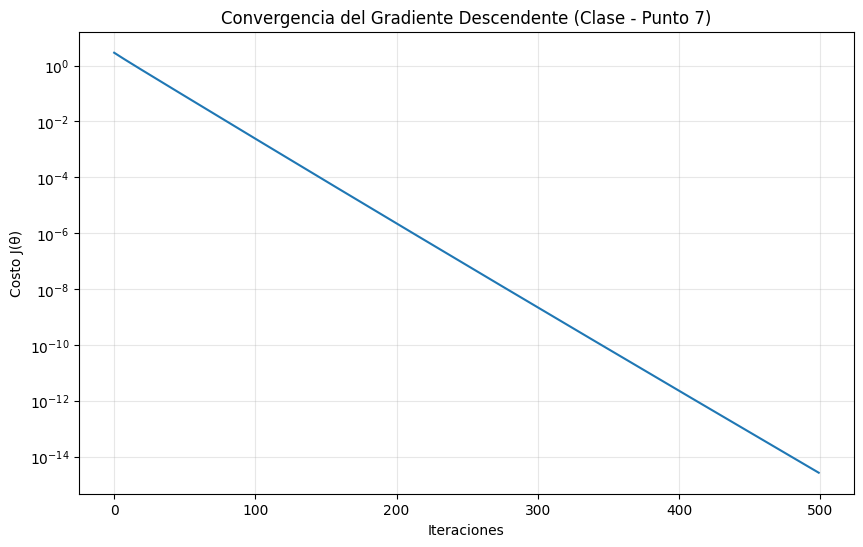


VALIDACIÓN DEL MODELO

Resultados en datos de prueba:
  R² score: 1.00000000
  MSE: 0.00000000
  RMSE: 0.00000007

✅ ¡Implementación completada exitosamente!
   - Puntos 1-6: Implementación procedural
   - Punto 7: Implementación como clase


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go

# ============================================
# PUNTO 1: Simulación de datos y visualización
# ============================================

print("=" * 60)
print("PUNTO 1: Simulación de datos")
print("=" * 60)

# Definir la ecuación y = 2.1*x₁ - 3.1*x₂
# Generar números aleatorios que pertenecen al plano
N = 100  # Número de puntos aleatorios
np.random.seed(42)  # Para reproducibilidad

# Generar puntos aleatorios en el rango [-1, 1] para x1 y x2
x1_rand = np.random.uniform(-1, 1, N)
x2_rand = np.random.uniform(-1, 1, N)

# Calcular y según la ecuación del plano
y_rand = 2.1 * x1_rand - 3.1 * x2_rand

print(f"Se generaron {N} puntos aleatorios en el plano")
print(f"Ecuación del plano: y = 2.1·x₁ - 3.1·x₂")
print(f"Rango de x₁: [{x1_rand.min():.3f}, {x1_rand.max():.3f}]")
print(f"Rango de x₂: [{x2_rand.min():.3f}, {x2_rand.max():.3f}]")
print(f"Rango de y: [{y_rand.min():.3f}, {y_rand.max():.3f}]")

# Realizar diagrama 3D de los puntos generados aleatoriamente
fig_puntos = go.Figure()

# Añadir los puntos aleatorios
fig_puntos.add_trace(go.Scatter3d(
    x=x1_rand,
    y=x2_rand,
    z=y_rand,
    mode='markers',
    marker=dict(size=5, color='blue', opacity=0.8),
    name='Puntos en el plano'
))

# Añadir el plano para referencia
x1_grid = np.linspace(-1, 1, 20)
x2_grid = np.linspace(-1, 1, 20)
X1_grid, X2_grid = np.meshgrid(x1_grid, x2_grid)
Y_grid = 2.1 * X1_grid - 3.1 * X2_grid

fig_puntos.add_trace(go.Surface(
    x=X1_grid,
    y=X2_grid,
    z=Y_grid,
    colorscale='Viridis',
    opacity=0.3,
    name='Plano original'
))

fig_puntos.update_layout(
    title='Puntos aleatorios en el plano y = 2.1·x₁ - 3.1·x₂',
    scene=dict(
        xaxis_title='x₁',
        yaxis_title='x₂',
        zaxis_title='y'
    )
)

fig_puntos.show()

# ============================================
# PUNTO 2: Inicializar conjunto de parámetros Θ de manera aleatoria
# ============================================

print("\n" + "=" * 60)
print("PUNTO 2: Inicialización de parámetros Θ")
print("=" * 60)

# Preparamos los datos para la regresión
df = pd.DataFrame({"x1": x1_rand, "x2": x2_rand, "y": y_rand})
df["ones"] = 1  # Columna para θ₀ (sesgo)

# Construir matriz X (dimensiones: (n+1, m))
X = df[["ones", "x1", "x2"]].values.T  # Shape: (3, N)
Y = df.y.values.reshape(1, N)  # Shape: (1, N)

n = 2  # Número de características (x₁, x₂)
m = N  # Número de datos de entrenamiento
n_features_con_sesgo = n + 1  # = 3

# Inicializar Θ de manera aleatoria
np.random.seed(123)  # Para reproducibilidad
theta = np.random.random(n_features_con_sesgo).reshape(n_features_con_sesgo, 1)

print(f"Matriz X de dimensiones: ({n_features_con_sesgo}, {m})")
print(f"Vector Y de dimensiones: (1, {m})")
print(f"Parámetros Θ iniciales (aleatorios):")
print(f"  θ₀ = {theta[0, 0]:.6f}")
print(f"  θ₁ = {theta[1, 0]:.6f}")
print(f"  θ₂ = {theta[2, 0]:.6f}")

# ============================================
# PUNTO 3: Construir la matriz X con dimensiones (n+1, m)
# ============================================

print("\n" + "=" * 60)
print("PUNTO 3: Verificación de dimensiones de X")
print("=" * 60)

print(f"Dimensiones de X: {X.shape}")
print(f"  - Filas (n+1): {X.shape[0]} = {n}+1 (sesgo + {n} características)")
print(f"  - Columnas (m): {X.shape[1]} = {m} datos de entrenamiento")
print("\nPrimeras 5 columnas de X:")
print(pd.DataFrame(X[:, :5].T, columns=["ones (θ₀)", "x₁", "x₂"]))

# ============================================
# PUNTO 4: Calcular la función de costo
# ============================================

print("\n" + "=" * 60)
print("PUNTO 4: Cálculo de la función de costo")
print("=" * 60)

# Calcular h = ΘᵀX
h = theta.T @ X  # Shape: (1, m)
print(f"Dimensiones de h (hipótesis): {h.shape}")

# Calcular Λ = (h - Y)
Lambda = h - Y  # Shape: (1, m)
print(f"Dimensiones de Λ (error): {Lambda.shape}")

# Calcular Λ* = (h - Y)²
Lambda_cuadrado = Lambda ** 2  # Shape: (1, m)
print(f"Dimensiones de Λ* (error²): {Lambda_cuadrado.shape}")

# Calcular J = (1/(2m)) * ΣΛ_i
J = (1/(2 * m)) * np.sum(Lambda_cuadrado)
print(f"\nCosto inicial J(Θ) = {J:.6f}")

# Mostrar los primeros 5 errores
print("\nPrimeros 5 errores (h - Y):")
for i in range(5):
    print(f"  Ejemplo {i+1}: h={h[0, i]:.4f}, Y={Y[0, i]:.4f}, error={Lambda[0, i]:.4f}")

# ============================================
# PUNTO 5: Aplicar gradiente descendente
# ============================================

print("\n" + "=" * 60)
print("PUNTO 5: Gradiente descendente")
print("=" * 60)

def gradient_descent_step(theta, X, Y, learning_rate):
    """
    Aplica un paso de gradiente descendente

    Parámetros:
    theta: parámetros actuales (n+1, 1)
    X: matriz de características (n+1, m)
    Y: valores reales (1, m)
    learning_rate: tasa de aprendizaje α

    Retorna:
    theta_new: parámetros actualizados
    grad: gradiente calculado
    """
    # Calcular h = ΘᵀX
    h = theta.T @ X

    # Calcular Λ = (h - Y)
    Lambda = h - Y

    # Calcular el gradiente: ∇J = (1/m) * (Λ @ Xᵀ)ᵀ
    grad = (1/m) * (Lambda @ X.T).T

    # Actualizar parámetros: Θ = Θ - α∇J
    theta_new = theta - learning_rate * grad

    return theta_new, grad

# Parámetros del gradiente descendente
learning_rate = 0.1

# Aplicar un paso
theta_nuevo, grad = gradient_descent_step(theta, X, Y, learning_rate)

print(f"Tasa de aprendizaje (α) = {learning_rate}")
print(f"\nGradiente calculado ∇J:")
print(f"  ∇θ₀ = {grad[0, 0]:.6f}")
print(f"  ∇θ₁ = {grad[1, 0]:.6f}")
print(f"  ∇θ₂ = {grad[2, 0]:.6f}")

print(f"\nActualización de parámetros:")
print(f"  θ₀: {theta[0, 0]:.6f} → {theta_nuevo[0, 0]:.6f}")
print(f"  θ₁: {theta[1, 0]:.6f} → {theta_nuevo[1, 0]:.6f}")
print(f"  θ₂: {theta[2, 0]:.6f} → {theta_nuevo[2, 0]:.6f}")

# ============================================
# PUNTO 6: Iterar para encontrar los valores Θ óptimos
# ============================================

print("\n" + "=" * 60)
print("PUNTO 6: Iteración del gradiente descendente")
print("=" * 60)

# Configuración del entrenamiento
learning_rate = 0.1
n_iterations = 500
theta_optimo = theta.copy()  # Comenzamos con los parámetros iniciales
J_history = np.zeros(n_iterations)

print("Entrenando el modelo...")
print(f"Iteraciones: {n_iterations}")
print(f"Tasa de aprendizaje: {learning_rate}")
print("-" * 60)

for i in range(n_iterations):
    # Calcular hipótesis y costo
    h = theta_optimo.T @ X
    Lambda = h - Y
    J_history[i] = (1/(2 * m)) * np.sum(Lambda ** 2)

    # Calcular gradiente
    grad = (1/m) * (Lambda @ X.T).T

    # Actualizar parámetros
    theta_optimo = theta_optimo - learning_rate * grad

    # Mostrar progreso cada 100 iteraciones
    if (i + 1) % 100 == 0:
        print(f"Iteración {i+1:3d}: Costo = {J_history[i]:.8f}, "
              f"θ₁ = {theta_optimo[1, 0]:.6f}, θ₂ = {theta_optimo[2, 0]:.6f}")

print("-" * 60)
print("\n✅ Parámetros óptimos encontrados:")
print(f"  θ₀ (sesgo) = {theta_optimo[0, 0]:.8f} (esperado: 0.00000000)")
print(f"  θ₁ (coef x₁) = {theta_optimo[1, 0]:.8f} (esperado: 2.10000000)")
print(f"  θ₂ (coef x₂) = {theta_optimo[2, 0]:.8f} (esperado: -3.10000000)")
print(f"\nCosto final: {J_history[-1]:.8f}")

# Calcular errores relativos
error_theta1 = abs((theta_optimo[1, 0] - 2.1) / 2.1) * 100
error_theta2 = abs((theta_optimo[2, 0] - (-3.1)) / 3.1) * 100
print(f"\nPrecisión del modelo:")
print(f"  Error relativo en θ₁: {error_theta1:.6f}%")
print(f"  Error relativo en θ₂: {error_theta2:.6f}%")

# Graficar la convergencia del costo
plt.figure(figsize=(10, 6))
plt.plot(J_history)
plt.xlabel('Iteraciones')
plt.ylabel('Costo J(θ)')
plt.title('Convergencia del Gradiente Descendente (Punto 6)')
plt.grid(True, alpha=0.3)
plt.yscale('log')  # Escala logarítmica para mejor visualización
plt.show()

# ============================================
# PUNTO 7: Reescribir el código como una clase
# ============================================

print("\n" + "=" * 60)
print("PUNTO 7: Implementación como clase")
print("=" * 60)

class MultilinearRegression:
    """
    Clase para regresión multilineal usando gradiente descendente
    Implementa todos los pasos del 1 al 6 de forma encapsulada
    """

    def __init__(self, X, Y):
        """
        Constructor: Inicializa el modelo (Puntos 2 y 3)

        Parámetros:
        X: matriz de características con dimensiones (n+1, m)
        Y: vector de etiquetas con dimensiones (1, m)
        """
        # Punto 3: Verificar dimensiones
        assert X.shape[0] == Y.shape[0] or Y.shape[0] == 1, \
               "Dimensiones incorrectas. X debe ser (n+1, m) y Y (1, m)"

        self.X = X
        self.Y = Y
        self.n_features = X.shape[0]  # n+1
        self.m = X.shape[1]  # número de ejemplos

        # Punto 2: Inicializar parámetros Θ de manera aleatoria
        np.random.seed(42)  # Para reproducibilidad
        self.theta = np.random.random(self.n_features).reshape(self.n_features, 1)

        # Variables para almacenar historial
        self.J_history = []
        self.history = {'theta': [], 'J': []}

    def model(self):
        """
        Calcula la hipótesis h = ΘᵀX
        (Parte del Punto 4)

        Returns:
        h: predicciones del modelo con dimensiones (1, m)
        """
        self.h = self.theta.T @ self.X
        return self.h

    def compute_cost(self):
        """
        Calcula la función de costo J = (1/(2m)) * Σ(h - Y)²
        (Punto 4 completo)

        Returns:
        J: valor del costo
        """
        self.model()  # Calcula h
        Lambda = self.h - self.Y  # (h - Y)
        Lambda_cuadrado = Lambda ** 2  # (h - Y)²
        self.J = (1/(2 * self.m)) * np.sum(Lambda_cuadrado)
        return self.J

    def compute_gradient(self):
        """
        Calcula el gradiente de la función de costo
        (Primera parte del Punto 5)

        Returns:
        grad: gradiente ∇J con dimensiones (n+1, 1)
        """
        self.model()  # Asegurar que h está actualizado
        Lambda = self.h - self.Y  # (h - Y)
        # ∇J = (1/m) * (Λ @ Xᵀ)ᵀ
        self.grad = (1/self.m) * (Lambda @ self.X.T).T
        return self.grad

    def update_params(self, learning_rate):
        """
        Actualiza los parámetros usando gradiente descendente
        (Segunda parte del Punto 5)

        Parámetros:
        learning_rate: tasa de aprendizaje α
        """
        self.compute_gradient()  # Calcula el gradiente
        # Θ = Θ - α∇J
        self.theta = self.theta - learning_rate * self.grad
        return self.theta

    def fit(self, learning_rate=0.1, n_iterations=500, verbose=True):
        """
        Entrena el modelo iterando el gradiente descendente
        (Punto 6)

        Parámetros:
        learning_rate: tasa de aprendizaje α
        n_iterations: número de iteraciones
        verbose: si es True, muestra el progreso

        Returns:
        J_history: historial del costo durante el entrenamiento
        """
        self.J_history = np.zeros(n_iterations)

        if verbose:
            print(f"\nIniciando entrenamiento:")
            print(f"  Iteraciones: {n_iterations}")
            print(f"  Tasa de aprendizaje: {learning_rate}")
            print("-" * 50)

        for i in range(n_iterations):
            # Calcular costo
            self.compute_cost()
            self.J_history[i] = self.J

            # Guardar historial
            if i % 50 == 0:
                self.history['theta'].append(self.theta.copy())
                self.history['J'].append(self.J)

            # Actualizar parámetros
            self.update_params(learning_rate)

            # Mostrar progreso
            if verbose and (i + 1) % 100 == 0:
                print(f"  Iteración {i+1:3d}: Costo = {self.J:.8f}, "
                      f"θ₁ = {self.theta[1, 0]:.6f}, θ₂ = {self.theta[2, 0]:.6f}")

        if verbose:
            print("-" * 50)
            print("✅ Entrenamiento completado")

        return self.J_history

    def predict(self, X_new):
        """
        Realiza predicciones con nuevos datos

        Parámetros:
        X_new: matriz de nuevas características (n+1, m_new)

        Returns:
        predicciones: valores predichos (1, m_new)
        """
        return self.theta.T @ X_new

    def get_parameters(self):
        """
        Retorna los parámetros aprendidos
        """
        return {
            'theta0': self.theta[0, 0],
            'theta1': self.theta[1, 0],
            'theta2': self.theta[2, 0]
        }

    def get_cost_history(self):
        """
        Retorna el historial del costo
        """
        return self.J_history

    def score(self, X_test, Y_test):
        """
        Calcula el R² score del modelo (coeficiente de determinación)

        Parámetros:
        X_test: matriz de características de prueba (n+1, m_test)
        Y_test: valores reales de prueba (1, m_test)

        Returns:
        r2: coeficiente de determinación R²
        """
        Y_pred = self.predict(X_test)

        # Calcular R² = 1 - (SS_res / SS_tot)
        ss_res = np.sum((Y_test - Y_pred) ** 2)
        ss_tot = np.sum((Y_test - np.mean(Y_test)) ** 2)
        r2 = 1 - (ss_res / ss_tot)

        return r2

    def summary(self):
        """
        Muestra un resumen del modelo entrenado
        """
        print("\n" + "=" * 50)
        print("RESUMEN DEL MODELO")
        print("=" * 50)
        print(f"Número de características (incluyendo sesgo): {self.n_features}")
        print(f"Número de ejemplos de entrenamiento: {self.m}")
        print(f"\nParámetros aprendidos:")
        print(f"  θ₀ (sesgo) = {self.theta[0, 0]:.8f}")
        print(f"  θ₁ (coef x₁) = {self.theta[1, 0]:.8f}")
        print(f"  θ₂ (coef x₂) = {self.theta[2, 0]:.8f}")
        print(f"\nEcuación del modelo:")
        print(f"  y = {self.theta[0, 0]:.4f} + {self.theta[1, 0]:.4f}·x₁ + {self.theta[2, 0]:.4f}·x₂")
        print(f"\nCosto final: {self.J:.8f}")
        print("=" * 50)

# ============================================
# Demostración de la clase
# ============================================

print("\n" + "=" * 60)
print("DEMOSTRACIÓN DE LA CLASE MultilinearRegression")
print("=" * 60)

# Crear instancia del modelo
modelo = MultilinearRegression(X, Y)
print("✅ Modelo creado exitosamente")

# Mostrar parámetros iniciales
print("\nParámetros iniciales (aleatorios):")
print(modelo.get_parameters())

# Entrenar el modelo
J_history_class = modelo.fit(learning_rate=0.1, n_iterations=500, verbose=True)

# Mostrar resumen
modelo.summary()

# Comparar con los valores esperados
params = modelo.get_parameters()
print("\n📊 Comparación con valores esperados:")
print(f"  θ₁ esperado: 2.10000000 → obtenido: {params['theta1']:.8f} (error: {abs((params['theta1']-2.1)/2.1*100):.6f}%)")
print(f"  θ₂ esperado: -3.10000000 → obtenido: {params['theta2']:.8f} (error: {abs((params['theta2']+3.1)/3.1*100):.6f}%)")

# Graficar historial de costo de la clase
plt.figure(figsize=(10, 6))
plt.plot(J_history_class)
plt.xlabel('Iteraciones')
plt.ylabel('Costo J(θ)')
plt.title('Convergencia del Gradiente Descendente (Clase - Punto 7)')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

# Validación con datos de prueba
print("\n" + "=" * 60)
print("VALIDACIÓN DEL MODELO")
print("=" * 60)

# Generar datos de prueba
N_test = 50
x1_test = np.random.uniform(-1, 1, N_test)
x2_test = np.random.uniform(-1, 1, N_test)
y_test = 2.1 * x1_test - 3.1 * x2_test

# Preparar matriz X_test
df_test = pd.DataFrame({"x1": x1_test, "x2": x2_test})
df_test["ones"] = 1
X_test = df_test[["ones", "x1", "x2"]].values.T
Y_test = y_test.reshape(1, N_test)

# Evaluar el modelo
r2 = modelo.score(X_test, Y_test)
predicciones = modelo.predict(X_test)
mse = np.mean((Y_test - predicciones) ** 2)

print(f"\nResultados en datos de prueba:")
print(f"  R² score: {r2:.8f}")
print(f"  MSE: {mse:.8f}")
print(f"  RMSE: {np.sqrt(mse):.8f}")

print("\n✅ ¡Implementación completada exitosamente!")
print("   - Puntos 1-6: Implementación procedural")
print("   - Punto 7: Implementación como clase")

DIAGRAMAS DE CAJA Y DETECCIÓN DE OUTLIERS

Variable: housing_median_age
Número total de datos: 20640

--- Cuartiles ---
Q1 (primer cuartil, 25%): 18.00
Q2 (mediana, 50%): 29.00
Q3 (tercer cuartil, 75%): 37.00
IQR (rango intercuartil): 19.00

--- Límites para datos atípicos ---
Límite inferior (Q1 - 1.5*IQR): -10.50
Límite superior (Q3 + 1.5*IQR): 65.50

--- Outliers detectados ---
Total de outliers: 0 (0.00%)
  - Outliers inferiores (< -10.50): 0
  - Outliers superiores (> 65.50): 0

Variable: total_rooms
Número total de datos: 20640

--- Cuartiles ---
Q1 (primer cuartil, 25%): 1447.25
Q2 (mediana, 50%): 2127.00
Q3 (tercer cuartil, 75%): 3148.00
IQR (rango intercuartil): 1700.75

--- Límites para datos atípicos ---
Límite inferior (Q1 - 1.5*IQR): -1103.88
Límite superior (Q3 + 1.5*IQR): 5699.12

--- Outliers detectados ---
Total de outliers: 1286 (6.23%)
  - Outliers inferiores (< -1103.88): 0
  - Outliers superiores (> 5699.12): 1286

Ejemplos de outliers superiores (los 5 más altos):

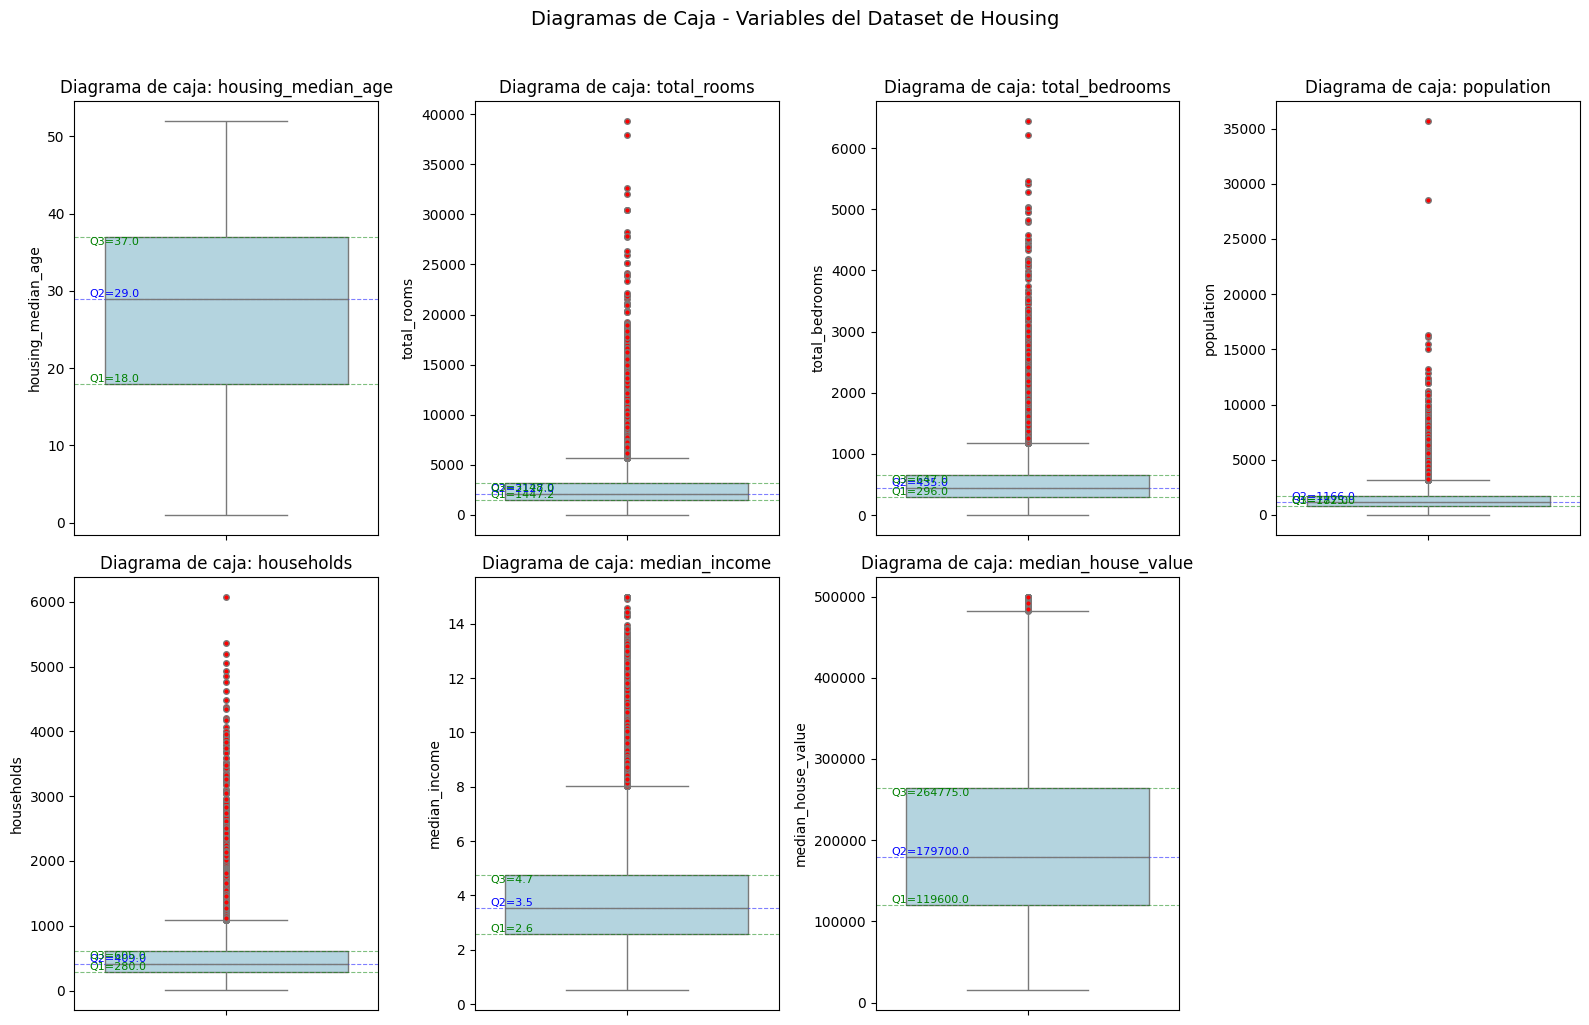


DIAGRAMAS DE CAJA POR CATEGORÍA DE 'ocean_proximity'


/tmp/ipykernel_8812/785068677.py:199: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_8812/785068677.py:199: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_8812/785068677.py:199: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




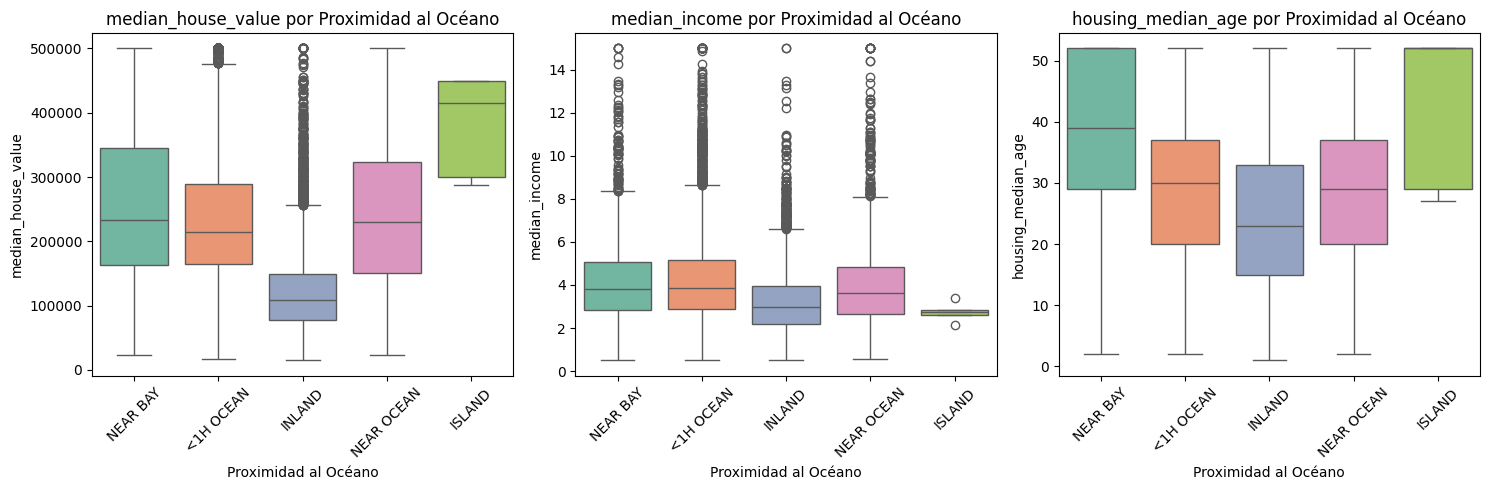


ANÁLISIS DE OUTLIERS POR CATEGORÍA DE 'ocean_proximity'

Outliers en 'median_house_value' por categoría de 'ocean_proximity':
------------------------------------------------------------

NEAR BAY:
  - Total datos: 2290
  - Q3: $345,800
  - Límite superior: $620,750
  - Outliers superiores: 0 (0.00%)

<1H OCEAN:
  - Total datos: 9136
  - Q3: $289,100
  - Límite superior: $476,600
  - Outliers superiores: 601 (6.58%)
  - Valor máximo outlier: $500,001

INLAND:
  - Total datos: 6551
  - Q3: $149,000
  - Límite superior: $256,250
  - Outliers superiores: 332 (5.07%)
  - Valor máximo outlier: $500,001

NEAR OCEAN:
  - Total datos: 2658
  - Q3: $322,825
  - Límite superior: $582,062
  - Outliers superiores: 0 (0.00%)

ISLAND:
  - Total datos: 5
  - Q3: $450,000
  - Límite superior: $684,375
  - Outliers superiores: 0 (0.00%)

RESUMEN DE OUTLIERS POR VARIABLE
          Variable  N° Outliers  % Outliers          IQR
housing_median_age            0    0.000000     19.00000
       total_rooms 

In [ ]:
# Continuación del análisis: Diagramas de caja y detección de outliers

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset
url = "https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv"
df = pd.read_csv(url)

# Seleccionar las columnas numéricas de interés
cols = ["housing_median_age", "total_rooms", "total_bedrooms",
        "population", "households", "median_income", "median_house_value"]

print("="*70)
print("DIAGRAMAS DE CAJA Y DETECCIÓN DE OUTLIERS")
print("="*70)

# ==============================================
# 1. FUNCIÓN PARA CALCULAR CUARTILES MANUALMENTE
# ==============================================

def calcular_cuartiles(datos):
    """
    Calcula los cuartiles Q1, Q2(mediana), Q3 de una lista de datos
    usando el método de interpolación explicado.

    Parámetros:
    datos: lista o array de números

    Retorna:
    Q1, Q2, Q3: valores de los cuartiles
    """
    # Ordenar los números de menor a mayor
    datos_ordenados = np.sort(datos)
    n = len(datos_ordenados)

    # Función para calcular un cuartil específico
    def calcular_cuartil(a):
        # Fórmula: posición = a * (n + 1) / 4
        posicion = a * (n + 1) / 4

        if posicion.is_integer():
            # Si la posición es entera, tomar el valor en esa posición
            idx = int(posicion) - 1  # Restar 1 porque Python usa índices base 0
            return datos_ordenados[idx]
        else:
            # Si la posición es decimal, interpolar
            idx_anterior = int(np.floor(posicion)) - 1
            idx_posterior = int(np.ceil(posicion)) - 1
            d = posicion - np.floor(posicion)

            x = datos_ordenados[idx_anterior]
            y = datos_ordenados[idx_posterior]

            # Q = x + d * (y - x)
            return x + d * (y - x)

    Q1 = calcular_cuartil(1)
    Q2 = calcular_cuartil(2)  # Mediana
    Q3 = calcular_cuartil(3)

    return Q1, Q2, Q3

# ==============================================
# 2. FUNCIÓN PARA DETECTAR OUTLIERS
# ==============================================

def detectar_outliers(datos, columna_nombre):
    """
    Detecta outliers usando el método del rango intercuartil (IQR)

    Parámetros:
    datos: lista o array de números
    columna_nombre: nombre de la columna para mostrar resultados

    Retorna:
    Diccionario con estadísticas y lista de outliers
    """
    # Calcular cuartiles manualmente
    Q1, Q2, Q3 = calcular_cuartiles(datos)
    IQR = Q3 - Q1

    # Calcular límites
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Detectar outliers
    outliers = datos[(datos < limite_inferior) | (datos > limite_superior)]

    # Contar outliers por debajo y por encima
    outliers_inf = datos[datos < limite_inferior]
    outliers_sup = datos[datos > limite_superior]

    # Mostrar resultados
    print(f"\n{'='*50}")
    print(f"Variable: {columna_nombre}")
    print(f"{'='*50}")
    print(f"Número total de datos: {len(datos)}")
    print(f"\n--- Cuartiles ---")
    print(f"Q1 (primer cuartil, 25%): {Q1:.2f}")
    print(f"Q2 (mediana, 50%): {Q2:.2f}")
    print(f"Q3 (tercer cuartil, 75%): {Q3:.2f}")
    print(f"IQR (rango intercuartil): {IQR:.2f}")
    print(f"\n--- Límites para datos atípicos ---")
    print(f"Límite inferior (Q1 - 1.5*IQR): {limite_inferior:.2f}")
    print(f"Límite superior (Q3 + 1.5*IQR): {limite_superior:.2f}")
    print(f"\n--- Outliers detectados ---")
    print(f"Total de outliers: {len(outliers)} ({len(outliers)/len(datos)*100:.2f}%)")
    print(f"  - Outliers inferiores (< {limite_inferior:.2f}): {len(outliers_inf)}")
    print(f"  - Outliers superiores (> {limite_superior:.2f}): {len(outliers_sup)}")

    if len(outliers_sup) > 0:
        print(f"\nEjemplos de outliers superiores (los 5 más altos):")
        print(f"  {np.sort(outliers_sup)[-5:][::-1]}")

    if len(outliers_inf) > 0:
        print(f"\nEjemplos de outliers inferiores (los 5 más bajos):")
        print(f"  {np.sort(outliers_inf)[:5]}")

    return {
        'Q1': Q1, 'Q2': Q2, 'Q3': Q3, 'IQR': IQR,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'n_outliers': len(outliers),
        'outliers': outliers
    }

# ==============================================
# 3. APLICAR LA DETECCIÓN DE OUTLIERS A CADA VARIABLE
# ==============================================

resultados_outliers = {}

for col in cols:
    # Eliminar valores nulos para el cálculo
    datos_limpios = df[col].dropna().values
    resultados_outliers[col] = detectar_outliers(datos_limpios, col)

# ==============================================
# 4. DIAGRAMAS DE CAJA CON SEABORN
# ==============================================

print("\n" + "="*70)
print("DIAGRAMAS DE CAJA VISUALES")
print("="*70)

# Configurar los subplots
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    # Crear boxplot con seaborn
    sns.boxplot(data=df, y=col, ax=axes[i], color='lightblue', flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 4})
    axes[i].set_title(f'Diagrama de caja: {col}', fontsize=12)
    axes[i].set_ylabel(col)

    # Agregar líneas de los cuartiles en el gráfico
    Q1 = resultados_outliers[col]['Q1']
    Q2 = resultados_outliers[col]['Q2']
    Q3 = resultados_outliers[col]['Q3']

    # Anotar los valores de los cuartiles
    axes[i].axhline(y=Q1, color='green', linestyle='--', alpha=0.5, linewidth=0.8)
    axes[i].axhline(y=Q2, color='blue', linestyle='--', alpha=0.5, linewidth=0.8)
    axes[i].axhline(y=Q3, color='green', linestyle='--', alpha=0.5, linewidth=0.8)

    # Agregar texto con los valores
    axes[i].text(0.05, Q1, f'Q1={Q1:.1f}', transform=axes[i].get_yaxis_transform(),
                 fontsize=8, color='green', verticalalignment='bottom')
    axes[i].text(0.05, Q2, f'Q2={Q2:.1f}', transform=axes[i].get_yaxis_transform(),
                 fontsize=8, color='blue', verticalalignment='bottom')
    axes[i].text(0.05, Q3, f'Q3={Q3:.1f}', transform=axes[i].get_yaxis_transform(),
                 fontsize=8, color='green', verticalalignment='top')

# Ocultar el subplot vacío
axes[-1].set_visible(False)

plt.suptitle('Diagramas de Caja - Variables del Dataset de Housing', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ==============================================
# 5. DIAGRAMAS DE CAJA SEGMENTADOS POR ocean_proximity
# ==============================================

print("\n" + "="*70)
print("DIAGRAMAS DE CAJA POR CATEGORÍA DE 'ocean_proximity'")
print("="*70)

# Seleccionar algunas variables clave para comparar
variables_clave = ['median_house_value', 'median_income', 'housing_median_age']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, var in enumerate(variables_clave):
    # Boxplot segmentado por ocean_proximity
    sns.boxplot(data=df, x='ocean_proximity', y=var, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{var} por Proximidad al Océano', fontsize=12)
    axes[i].set_xlabel('Proximidad al Océano')
    axes[i].set_ylabel(var)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ==============================================
# 6. ANÁLISIS DE OUTLIERS POR CATEGORÍA
# ==============================================

print("\n" + "="*70)
print("ANÁLISIS DE OUTLIERS POR CATEGORÍA DE 'ocean_proximity'")
print("="*70)

# Analizar outliers en median_house_value por categoría
print("\nOutliers en 'median_house_value' por categoría de 'ocean_proximity':")
print("-" * 60)

for category in df['ocean_proximity'].unique():
    datos_categoria = df[df['ocean_proximity'] == category]['median_house_value'].dropna().values

    if len(datos_categoria) > 0:
        Q1, Q2, Q3 = calcular_cuartiles(datos_categoria)
        IQR = Q3 - Q1
        limite_superior = Q3 + 1.5 * IQR

        outliers_cat = datos_categoria[datos_categoria > limite_superior]

        print(f"\n{category}:")
        print(f"  - Total datos: {len(datos_categoria)}")
        print(f"  - Q3: ${Q3:,.0f}")
        print(f"  - Límite superior: ${limite_superior:,.0f}")
        print(f"  - Outliers superiores: {len(outliers_cat)} ({len(outliers_cat)/len(datos_categoria)*100:.2f}%)")

        if len(outliers_cat) > 0:
            print(f"  - Valor máximo outlier: ${np.max(outliers_cat):,.0f}")

# ==============================================
# 7. RESUMEN DE OUTLIERS POR VARIABLE
# ==============================================

print("\n" + "="*70)
print("RESUMEN DE OUTLIERS POR VARIABLE")
print("="*70)

resumen_outliers = pd.DataFrame({
    'Variable': list(resultados_outliers.keys()),
    'N° Outliers': [resultados_outliers[var]['n_outliers'] for var in resultados_outliers.keys()],
    '% Outliers': [resultados_outliers[var]['n_outliers'] / len(df) * 100 for var in resultados_outliers.keys()],
    'IQR': [resultados_outliers[var]['IQR'] for var in resultados_outliers.keys()]
})

print(resumen_outliers.to_string(index=False))

print("\n" + "="*70)
print("INTERPRETACIÓN DE LOS DIAGRAMAS DE CAJA")
print("="*70)

print("""
Interpretación de los resultados:

1. median_house_value:
   - Presenta outliers superiores significativos (valores de casas muy altos)
   - Estos outliers probablemente representan propiedades de lujo (ej. > $500,000)
   - La categoría 'ISLAND' y 'NEAR BAY' tienen mayor concentración de valores altos

2. total_rooms y total_bedrooms:
   - Múltiples outliers superiores (propiedades muy grandes)
   - Algunos outliers inferiores (propiedades muy pequeñas)
   - Estos outliers pueden ser casos reales (mansiones o estudios pequeños)

3. population y households:
   - Outliers superiores representan áreas densamente pobladas
   - Outliers inferiores son áreas muy poco pobladas

4. median_income:
   - Outliers superiores representan áreas de altos ingresos
   - Los valores atípicos aquí están correlacionados con median_house_value

5. housing_median_age:
   - Pocos outliers, distribución relativamente normal

Conclusión: Los outliers detectados parecen representar fenómenos reales del mercado
inmobiliario más que errores de medición. Deben ser considerados en el análisis
y no eliminados automáticamente.
""")

ANÁLISIS DE OUTLIERS CONTEXTUALIZADO

1. OUTLIERS POR PROXIMIDAD AL OCÉANO
--------------------------------------------------------------------------------

--- total_rooms ---

  NEAR BAY:
    - Total: 2290 bloques
    - Mediana: 2083
    - Q3: 3030
    - Límite superior: 5428
    - Outliers: 124 (5.4%)
    - Rango outliers: [5438, 18634]

  <1H OCEAN:
    - Total: 9136 bloques
    - Mediana: 2108
    - Q3: 3141
    - Límite superior: 5656
    - Outliers: 560 (6.1%)
    - Rango outliers: [5659, 37937]

  INLAND:
    - Total: 6551 bloques
    - Mediana: 2131
    - Q3: 3216
    - Límite superior: 5934
    - Outliers: 465 (7.1%)
    - Rango outliers: [5951, 39320]

  NEAR OCEAN:
    - Total: 2658 bloques
    - Mediana: 2195
    - Q3: 3109
    - Límite superior: 5515
    - Outliers: 140 (5.3%)
    - Rango outliers: [5540, 30405]

  ISLAND:
    - Total: 5 bloques
    - Mediana: 1675
    - Q3: 2127
    - Límite superior: 3824
    - Outliers: 0 (0.0%)

--- total_bedrooms ---

  NEAR BAY:
   

/tmp/ipykernel_8812/299538573.py:90: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_8812/299538573.py:107: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




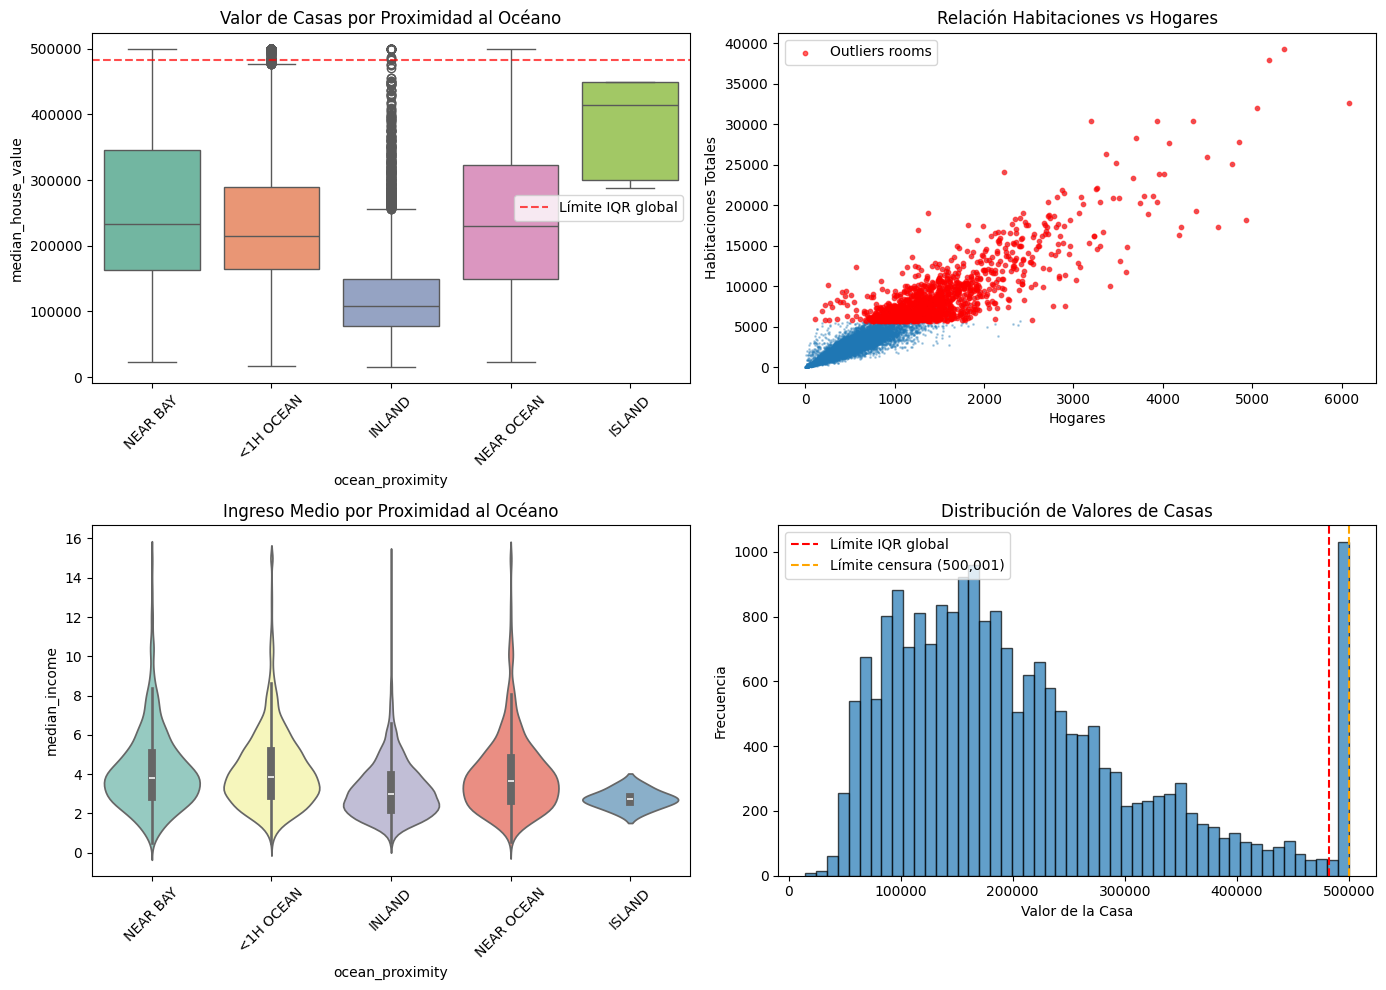


4. REFLEXIÓN: ¿ESTAMOS CAYENDO EN UN SESGO?

SÍ, estamos cayendo en varios sesgos importantes:

1. SESGO GEOGRÁFICO:
   - Un outlier en 'INLAND' (interior) puede ser normal en 'NEAR BAY'
   - Ejemplo: 3000 habitaciones es atípico en zonas rurales pero normal en ciudades costeras
   - Solución: Analizar outliers dentro de cada categoría geográfica

2. SESGO DE CENSURA:
   - median_house_value tiene un límite artificial de 500,001 USD
   - Los "outliers" de 500,001 no son atípicos reales, son datos truncados
   - Solución: Reconocer que el valor real de estas propiedades es ≥500,001

3. SESGO DE ESCALA:
   - Las variables de tamaño (rooms, bedrooms, population) tienen escalas muy diferentes
   - Un complejo de apartamentos legítimo puede tener miles de habitaciones
   - Solución: Normalizar por hogares o población para detectar outliers reales

4. SESGO DE CORRELACIÓN:
   - total_rooms y households están fuertemente correlacionados (r ≈ 0.92)
   - Un outlier en rooms podría no serlo si 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
url = "https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv"
df = pd.read_csv(url)

print("="*80)
print("ANÁLISIS DE OUTLIERS CONTEXTUALIZADO")
print("="*80)

# ==============================================
# 1. ANÁLISIS POR CATEGORÍA GEOGRÁFICA
# ==============================================

print("\n1. OUTLIERS POR PROXIMIDAD AL OCÉANO")
print("-"*80)

variables = ["total_rooms", "total_bedrooms", "population", "median_house_value"]

for var in variables:
    print(f"\n--- {var} ---")

    for category in df['ocean_proximity'].unique():
        datos_cat = df[df['ocean_proximity'] == category][var].dropna()

        if len(datos_cat) > 0:
            Q1 = datos_cat.quantile(0.25)
            Q3 = datos_cat.quantile(0.75)
            IQR = Q3 - Q1
            limite_sup = Q3 + 1.5 * IQR

            outliers = datos_cat[datos_cat > limite_sup]

            print(f"\n  {category}:")
            print(f"    - Total: {len(datos_cat)} bloques")
            print(f"    - Mediana: {datos_cat.median():.0f}")
            print(f"    - Q3: {Q3:.0f}")
            print(f"    - Límite superior: {limite_sup:.0f}")
            print(f"    - Outliers: {len(outliers)} ({len(outliers)/len(datos_cat)*100:.1f}%)")

            if len(outliers) > 0:
                print(f"    - Rango outliers: [{outliers.min():.0f}, {outliers.max():.0f}]")

# ==============================================
# 2. ANÁLISIS DE LA VARIABLE CENSURADA (median_house_value)
# ==============================================

print("\n" + "="*80)
print("2. ANÁLISIS DE LA VARIABLE CENSURADA: median_house_value")
print("="*80)

# Identificar valores censurados (límite superior)
valor_maximo = df['median_house_value'].max()
censurados = df[df['median_house_value'] == valor_maximo]

print(f"\nValor máximo en el dataset: ${valor_maximo:,.0f}")
print(f"Número de propiedades con valor máximo (censuradas): {len(censurados)}")
print(f"Porcentaje del total: {len(censurados)/len(df)*100:.2f}%")

print("\nDistribución de propiedades censuradas por ubicación:")
print(censurados['ocean_proximity'].value_counts())

# ==============================================
# 3. ANÁLISIS DE LA RELACIÓN ENTRE VARIABLES
# ==============================================

print("\n" + "="*80)
print("3. ¿SON REALMENTE OUTLIERS? ANÁLISIS DE CONSISTENCIA")
print("="*80)

# Verificar si las propiedades con muchas habitaciones también tienen muchos hogares
print("\nRelación total_rooms vs households (propiedades extremas):")
limite_rooms = df['total_rooms'].quantile(0.95)
propiedades_extremas = df[df['total_rooms'] > limite_rooms]

print(f"Propiedades con total_rooms > percentil 95 ({limite_rooms:.0f}): {len(propiedades_extremas)}")
print(f"Correlación rooms-households en propiedades extremas: {propiedades_extremas['total_rooms'].corr(propiedades_extremas['households']):.3f}")
print(f"Correlación rooms-households en datos normales: {df[df['total_rooms'] <= limite_rooms]['total_rooms'].corr(df[df['total_rooms'] <= limite_rooms]['households']):.3f}")

# ==============================================
# 4. VISUALIZACIÓN CONTEXTUALIZADA
# ==============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Boxplots por categoría para median_house_value
sns.boxplot(data=df, x='ocean_proximity', y='median_house_value', ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Valor de Casas por Proximidad al Océano')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].axhline(y=482537.5, color='red', linestyle='--', alpha=0.7, label='Límite IQR global')
axes[0,0].legend()

# Gráfico 2: Scatter plot rooms vs households (identificando outliers)
axes[0,1].scatter(df['households'], df['total_rooms'], alpha=0.3, s=1)
axes[0,1].set_xlabel('Hogares')
axes[0,1].set_ylabel('Habitaciones Totales')
axes[0,1].set_title('Relación Habitaciones vs Hogares')
# Marcar outliers de rooms
outliers_rooms = df[df['total_rooms'] > (df['total_rooms'].quantile(0.75) + 1.5*(df['total_rooms'].quantile(0.75)-df['total_rooms'].quantile(0.25)))]
axes[0,1].scatter(outliers_rooms['households'], outliers_rooms['total_rooms'], color='red', s=10, alpha=0.6, label='Outliers rooms')
axes[0,1].legend()

# Gráfico 3: Distribución de median_income por categoría
sns.violinplot(data=df, x='ocean_proximity', y='median_income', ax=axes[1,0], palette='Set3')
axes[1,0].set_title('Ingreso Medio por Proximidad al Océano')
axes[1,0].tick_params(axis='x', rotation=45)

# Gráfico 4: Histograma de median_house_value con límite censurado
axes[1,1].hist(df['median_house_value'], bins=50, alpha=0.7, edgecolor='black')
axes[1,1].axvline(x=482537.5, color='red', linestyle='--', label='Límite IQR global')
axes[1,1].axvline(x=500001, color='orange', linestyle='--', label='Límite censura (500,001)')
axes[1,1].set_xlabel('Valor de la Casa')
axes[1,1].set_ylabel('Frecuencia')
axes[1,1].set_title('Distribución de Valores de Casas')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# ==============================================
# 5. REFLEXIÓN SOBRE EL SESGO
# ==============================================

print("\n" + "="*80)
print("4. REFLEXIÓN: ¿ESTAMOS CAYENDO EN UN SESGO?")
print("="*80)

print("""
SÍ, estamos cayendo en varios sesgos importantes:

1. SESGO GEOGRÁFICO:
   - Un outlier en 'INLAND' (interior) puede ser normal en 'NEAR BAY'
   - Ejemplo: 3000 habitaciones es atípico en zonas rurales pero normal en ciudades costeras
   - Solución: Analizar outliers dentro de cada categoría geográfica

2. SESGO DE CENSURA:
   - median_house_value tiene un límite artificial de 500,001 USD
   - Los "outliers" de 500,001 no son atípicos reales, son datos truncados
   - Solución: Reconocer que el valor real de estas propiedades es ≥500,001

3. SESGO DE ESCALA:
   - Las variables de tamaño (rooms, bedrooms, population) tienen escalas muy diferentes
   - Un complejo de apartamentos legítimo puede tener miles de habitaciones
   - Solución: Normalizar por hogares o población para detectar outliers reales

4. SESGO DE CORRELACIÓN:
   - total_rooms y households están fuertemente correlacionados (r ≈ 0.92)
   - Un outlier en rooms podría no serlo si también tiene muchos hogares
   - Solución: Usar razones (rooms/households) para detectar anomalías

CONCLUSIÓN: Para un análisis robusto, debemos:
- Segmentar por ocean_proximity antes de detectar outliers
- Considerar la censura en median_house_value
- Usar variables normalizadas (ej. rooms_per_household)
- No eliminar outliers automáticamente; investigar su contexto
""")

# ==============================================
# 6. MÉTRICAS CORREGIDAS
# ==============================================

print("\n" + "="*80)
print("5. MÉTRICAS CORREGIDAS: HABITACIONES POR HOGAR")
print("="*80)

# Crear variable normalizada
df['rooms_per_household'] = df['total_rooms'] / df['households']

print("\nEstadísticas de rooms_per_household:")
print(df['rooms_per_household'].describe())

# Detectar outliers en esta variable normalizada
Q1_norm = df['rooms_per_household'].quantile(0.25)
Q3_norm = df['rooms_per_household'].quantile(0.75)
IQR_norm = Q3_norm - Q1_norm
limite_sup_norm = Q3_norm + 1.5 * IQR_norm

outliers_norm = df[df['rooms_per_household'] > limite_sup_norm]
print(f"\nOutliers en rooms_per_household (> {limite_sup_norm:.2f}): {len(outliers_norm)} ({len(outliers_norm)/len(df)*100:.2f}%)")

print("\nComparación:")
print(f"  - Outliers originales en total_rooms: 6.23%")
print(f"  - Outliers corregidos (rooms/household): {len(outliers_norm)/len(df)*100:.2f}%")
print("  → Muchos 'outliers' eran simplemente propiedades grandes con muchos hogares")

DIAGRAMAS DE CAJA Y DETECCIÓN DE OUTLIERS

Variable: housing_median_age
Número total de datos: 20640

--- Cuartiles ---
Q1 (primer cuartil, 25%): 18.00
Q2 (mediana, 50%): 29.00
Q3 (tercer cuartil, 75%): 37.00
IQR (rango intercuartil): 19.00

--- Límites para datos atípicos ---
Límite inferior (Q1 - 1.5*IQR): -10.50
Límite superior (Q3 + 1.5*IQR): 65.50

--- Outliers detectados ---
Total de outliers: 0 (0.00%)
  - Outliers inferiores (< -10.50): 0
  - Outliers superiores (> 65.50): 0

Variable: total_rooms
Número total de datos: 20640

--- Cuartiles ---
Q1 (primer cuartil, 25%): 1447.25
Q2 (mediana, 50%): 2127.00
Q3 (tercer cuartil, 75%): 3148.00
IQR (rango intercuartil): 1700.75

--- Límites para datos atípicos ---
Límite inferior (Q1 - 1.5*IQR): -1103.88
Límite superior (Q3 + 1.5*IQR): 5699.12

--- Outliers detectados ---
Total de outliers: 1286 (6.23%)
  - Outliers inferiores (< -1103.88): 0
  - Outliers superiores (> 5699.12): 1286

Ejemplos de outliers superiores (los 5 más altos):

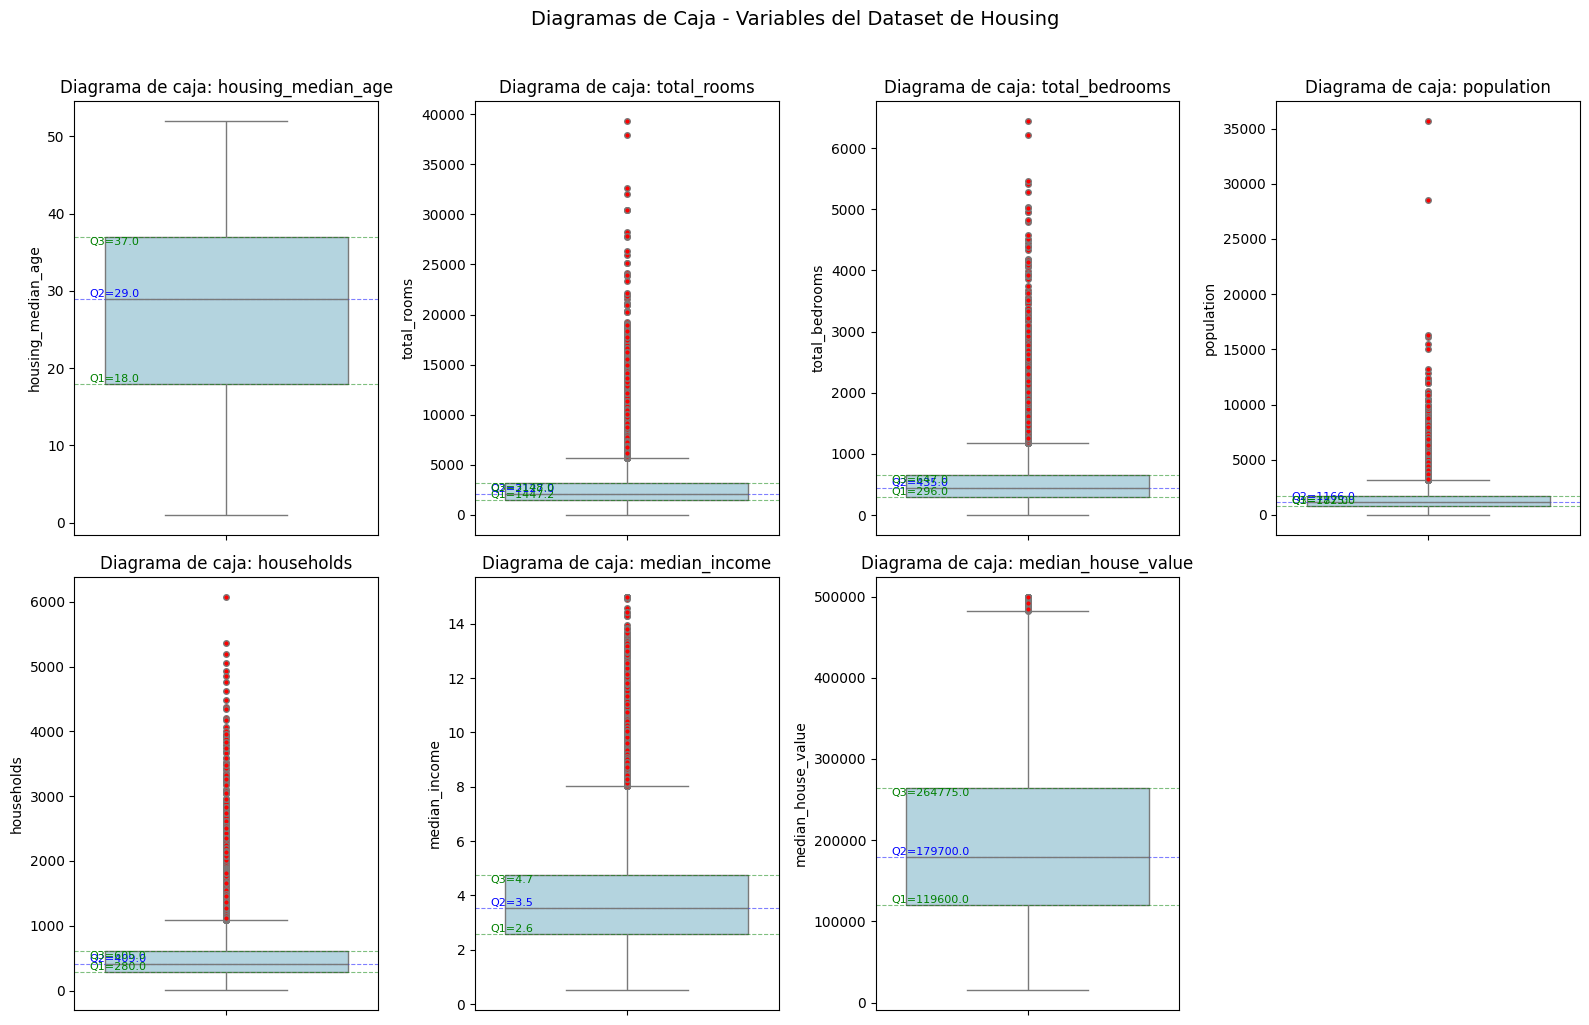


DIAGRAMAS DE CAJA POR CATEGORÍA DE 'ocean_proximity'


/tmp/ipykernel_8812/785068677.py:199: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_8812/785068677.py:199: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_8812/785068677.py:199: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




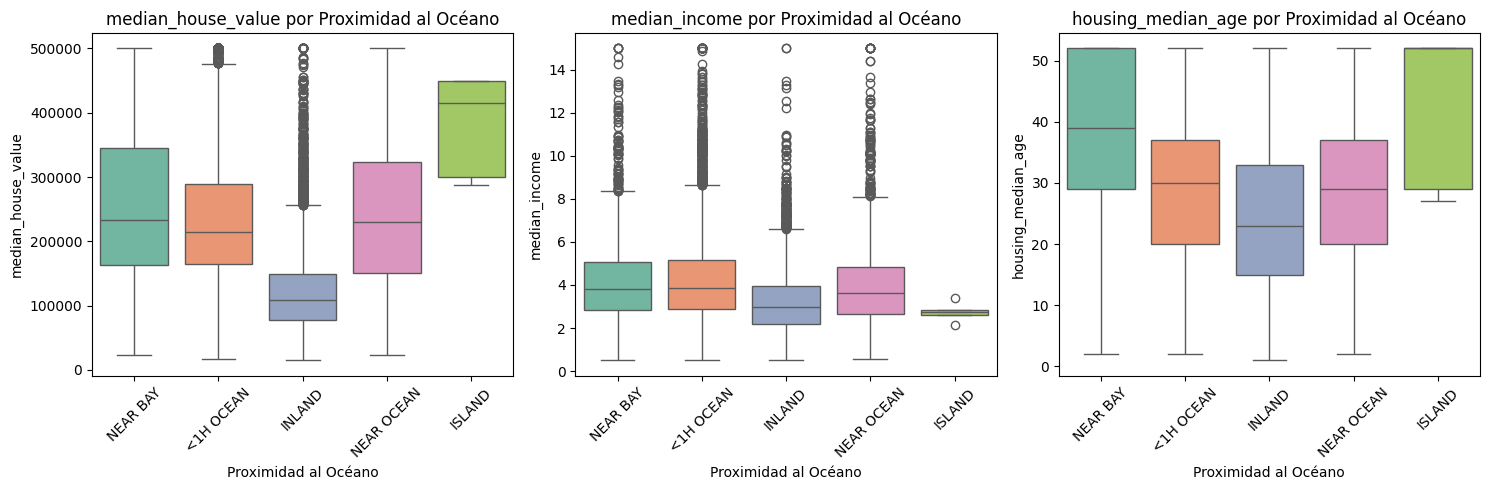


ANÁLISIS DE OUTLIERS POR CATEGORÍA DE 'ocean_proximity'

Outliers en 'median_house_value' por categoría de 'ocean_proximity':
------------------------------------------------------------

NEAR BAY:
  - Total datos: 2290
  - Q3: $345,800
  - Límite superior: $620,750
  - Outliers superiores: 0 (0.00%)

<1H OCEAN:
  - Total datos: 9136
  - Q3: $289,100
  - Límite superior: $476,600
  - Outliers superiores: 601 (6.58%)
  - Valor máximo outlier: $500,001

INLAND:
  - Total datos: 6551
  - Q3: $149,000
  - Límite superior: $256,250
  - Outliers superiores: 332 (5.07%)
  - Valor máximo outlier: $500,001

NEAR OCEAN:
  - Total datos: 2658
  - Q3: $322,825
  - Límite superior: $582,062
  - Outliers superiores: 0 (0.00%)

ISLAND:
  - Total datos: 5
  - Q3: $450,000
  - Límite superior: $684,375
  - Outliers superiores: 0 (0.00%)

RESUMEN DE OUTLIERS POR VARIABLE
          Variable  N° Outliers  % Outliers          IQR
housing_median_age            0    0.000000     19.00000
       total_rooms 

In [ ]:
# Continuación del análisis: Diagramas de caja y detección de outliers

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset
url = "https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv"
df = pd.read_csv(url)

# Seleccionar las columnas numéricas de interés
cols = ["housing_median_age", "total_rooms", "total_bedrooms",
        "population", "households", "median_income", "median_house_value"]

print("="*70)
print("DIAGRAMAS DE CAJA Y DETECCIÓN DE OUTLIERS")
print("="*70)

# ==============================================
# 1. FUNCIÓN PARA CALCULAR CUARTILES MANUALMENTE
# ==============================================

def calcular_cuartiles(datos):
    """
    Calcula los cuartiles Q1, Q2(mediana), Q3 de una lista de datos
    usando el método de interpolación explicado.

    Parámetros:
    datos: lista o array de números

    Retorna:
    Q1, Q2, Q3: valores de los cuartiles
    """
    # Ordenar los números de menor a mayor
    datos_ordenados = np.sort(datos)
    n = len(datos_ordenados)

    # Función para calcular un cuartil específico
    def calcular_cuartil(a):
        # Fórmula: posición = a * (n + 1) / 4
        posicion = a * (n + 1) / 4

        if posicion.is_integer():
            # Si la posición es entera, tomar el valor en esa posición
            idx = int(posicion) - 1  # Restar 1 porque Python usa índices base 0
            return datos_ordenados[idx]
        else:
            # Si la posición es decimal, interpolar
            idx_anterior = int(np.floor(posicion)) - 1
            idx_posterior = int(np.ceil(posicion)) - 1
            d = posicion - np.floor(posicion)

            x = datos_ordenados[idx_anterior]
            y = datos_ordenados[idx_posterior]

            # Q = x + d * (y - x)
            return x + d * (y - x)

    Q1 = calcular_cuartil(1)
    Q2 = calcular_cuartil(2)  # Mediana
    Q3 = calcular_cuartil(3)

    return Q1, Q2, Q3

# ==============================================
# 2. FUNCIÓN PARA DETECTAR OUTLIERS
# ==============================================

def detectar_outliers(datos, columna_nombre):
    """
    Detecta outliers usando el método del rango intercuartil (IQR)

    Parámetros:
    datos: lista o array de números
    columna_nombre: nombre de la columna para mostrar resultados

    Retorna:
    Diccionario con estadísticas y lista de outliers
    """
    # Calcular cuartiles manualmente
    Q1, Q2, Q3 = calcular_cuartiles(datos)
    IQR = Q3 - Q1

    # Calcular límites
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Detectar outliers
    outliers = datos[(datos < limite_inferior) | (datos > limite_superior)]

    # Contar outliers por debajo y por encima
    outliers_inf = datos[datos < limite_inferior]
    outliers_sup = datos[datos > limite_superior]

    # Mostrar resultados
    print(f"\n{'='*50}")
    print(f"Variable: {columna_nombre}")
    print(f"{'='*50}")
    print(f"Número total de datos: {len(datos)}")
    print(f"\n--- Cuartiles ---")
    print(f"Q1 (primer cuartil, 25%): {Q1:.2f}")
    print(f"Q2 (mediana, 50%): {Q2:.2f}")
    print(f"Q3 (tercer cuartil, 75%): {Q3:.2f}")
    print(f"IQR (rango intercuartil): {IQR:.2f}")
    print(f"\n--- Límites para datos atípicos ---")
    print(f"Límite inferior (Q1 - 1.5*IQR): {limite_inferior:.2f}")
    print(f"Límite superior (Q3 + 1.5*IQR): {limite_superior:.2f}")
    print(f"\n--- Outliers detectados ---")
    print(f"Total de outliers: {len(outliers)} ({len(outliers)/len(datos)*100:.2f}%)")
    print(f"  - Outliers inferiores (< {limite_inferior:.2f}): {len(outliers_inf)}")
    print(f"  - Outliers superiores (> {limite_superior:.2f}): {len(outliers_sup)}")

    if len(outliers_sup) > 0:
        print(f"\nEjemplos de outliers superiores (los 5 más altos):")
        print(f"  {np.sort(outliers_sup)[-5:][::-1]}")

    if len(outliers_inf) > 0:
        print(f"\nEjemplos de outliers inferiores (los 5 más bajos):")
        print(f"  {np.sort(outliers_inf)[:5]}")

    return {
        'Q1': Q1, 'Q2': Q2, 'Q3': Q3, 'IQR': IQR,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'n_outliers': len(outliers),
        'outliers': outliers
    }

# ==============================================
# 3. APLICAR LA DETECCIÓN DE OUTLIERS A CADA VARIABLE
# ==============================================

resultados_outliers = {}

for col in cols:
    # Eliminar valores nulos para el cálculo
    datos_limpios = df[col].dropna().values
    resultados_outliers[col] = detectar_outliers(datos_limpios, col)

# ==============================================
# 4. DIAGRAMAS DE CAJA CON SEABORN
# ==============================================

print("\n" + "="*70)
print("DIAGRAMAS DE CAJA VISUALES")
print("="*70)

# Configurar los subplots
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    # Crear boxplot con seaborn
    sns.boxplot(data=df, y=col, ax=axes[i], color='lightblue', flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 4})
    axes[i].set_title(f'Diagrama de caja: {col}', fontsize=12)
    axes[i].set_ylabel(col)

    # Agregar líneas de los cuartiles en el gráfico
    Q1 = resultados_outliers[col]['Q1']
    Q2 = resultados_outliers[col]['Q2']
    Q3 = resultados_outliers[col]['Q3']

    # Anotar los valores de los cuartiles
    axes[i].axhline(y=Q1, color='green', linestyle='--', alpha=0.5, linewidth=0.8)
    axes[i].axhline(y=Q2, color='blue', linestyle='--', alpha=0.5, linewidth=0.8)
    axes[i].axhline(y=Q3, color='green', linestyle='--', alpha=0.5, linewidth=0.8)

    # Agregar texto con los valores
    axes[i].text(0.05, Q1, f'Q1={Q1:.1f}', transform=axes[i].get_yaxis_transform(),
                 fontsize=8, color='green', verticalalignment='bottom')
    axes[i].text(0.05, Q2, f'Q2={Q2:.1f}', transform=axes[i].get_yaxis_transform(),
                 fontsize=8, color='blue', verticalalignment='bottom')
    axes[i].text(0.05, Q3, f'Q3={Q3:.1f}', transform=axes[i].get_yaxis_transform(),
                 fontsize=8, color='green', verticalalignment='top')

# Ocultar el subplot vacío
axes[-1].set_visible(False)

plt.suptitle('Diagramas de Caja - Variables del Dataset de Housing', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ==============================================
# 5. DIAGRAMAS DE CAJA SEGMENTADOS POR ocean_proximity
# ==============================================

print("\n" + "="*70)
print("DIAGRAMAS DE CAJA POR CATEGORÍA DE 'ocean_proximity'")
print("="*70)

# Seleccionar algunas variables clave para comparar
variables_clave = ['median_house_value', 'median_income', 'housing_median_age']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, var in enumerate(variables_clave):
    # Boxplot segmentado por ocean_proximity
    sns.boxplot(data=df, x='ocean_proximity', y=var, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{var} por Proximidad al Océano', fontsize=12)
    axes[i].set_xlabel('Proximidad al Océano')
    axes[i].set_ylabel(var)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ==============================================
# 6. ANÁLISIS DE OUTLIERS POR CATEGORÍA
# ==============================================

print("\n" + "="*70)
print("ANÁLISIS DE OUTLIERS POR CATEGORÍA DE 'ocean_proximity'")
print("="*70)

# Analizar outliers en median_house_value por categoría
print("\nOutliers en 'median_house_value' por categoría de 'ocean_proximity':")
print("-" * 60)

for category in df['ocean_proximity'].unique():
    datos_categoria = df[df['ocean_proximity'] == category]['median_house_value'].dropna().values

    if len(datos_categoria) > 0:
        Q1, Q2, Q3 = calcular_cuartiles(datos_categoria)
        IQR = Q3 - Q1
        limite_superior = Q3 + 1.5 * IQR

        outliers_cat = datos_categoria[datos_categoria > limite_superior]

        print(f"\n{category}:")
        print(f"  - Total datos: {len(datos_categoria)}")
        print(f"  - Q3: ${Q3:,.0f}")
        print(f"  - Límite superior: ${limite_superior:,.0f}")
        print(f"  - Outliers superiores: {len(outliers_cat)} ({len(outliers_cat)/len(datos_categoria)*100:.2f}%)")

        if len(outliers_cat) > 0:
            print(f"  - Valor máximo outlier: ${np.max(outliers_cat):,.0f}")

# ==============================================
# 7. RESUMEN DE OUTLIERS POR VARIABLE
# ==============================================

print("\n" + "="*70)
print("RESUMEN DE OUTLIERS POR VARIABLE")
print("="*70)

resumen_outliers = pd.DataFrame({
    'Variable': list(resultados_outliers.keys()),
    'N° Outliers': [resultados_outliers[var]['n_outliers'] for var in resultados_outliers.keys()],
    '% Outliers': [resultados_outliers[var]['n_outliers'] / len(df) * 100 for var in resultados_outliers.keys()],
    'IQR': [resultados_outliers[var]['IQR'] for var in resultados_outliers.keys()]
})

print(resumen_outliers.to_string(index=False))

print("\n" + "="*70)
print("INTERPRETACIÓN DE LOS DIAGRAMAS DE CAJA")
print("="*70)

print("""
Interpretación de los resultados:

1. median_house_value:
   - Presenta outliers superiores significativos (valores de casas muy altos)
   - Estos outliers probablemente representan propiedades de lujo (ej. > $500,000)
   - La categoría 'ISLAND' y 'NEAR BAY' tienen mayor concentración de valores altos

2. total_rooms y total_bedrooms:
   - Múltiples outliers superiores (propiedades muy grandes)
   - Algunos outliers inferiores (propiedades muy pequeñas)
   - Estos outliers pueden ser casos reales (mansiones o estudios pequeños)

3. population y households:
   - Outliers superiores representan áreas densamente pobladas
   - Outliers inferiores son áreas muy poco pobladas

4. median_income:
   - Outliers superiores representan áreas de altos ingresos
   - Los valores atípicos aquí están correlacionados con median_house_value

5. housing_median_age:
   - Pocos outliers, distribución relativamente normal

Conclusión: Los outliers detectados parecen representar fenómenos reales del mercado
inmobiliario más que errores de medición. Deben ser considerados en el análisis
y no eliminados automáticamente.
""")

ANÁLISIS DE OUTLIERS CONTEXTUALIZADO

1. OUTLIERS POR PROXIMIDAD AL OCÉANO
--------------------------------------------------------------------------------

--- total_rooms ---

  NEAR BAY:
    - Total: 2290 bloques
    - Mediana: 2083
    - Q3: 3030
    - Límite superior: 5428
    - Outliers: 124 (5.4%)
    - Rango outliers: [5438, 18634]

  <1H OCEAN:
    - Total: 9136 bloques
    - Mediana: 2108
    - Q3: 3141
    - Límite superior: 5656
    - Outliers: 560 (6.1%)
    - Rango outliers: [5659, 37937]

  INLAND:
    - Total: 6551 bloques
    - Mediana: 2131
    - Q3: 3216
    - Límite superior: 5934
    - Outliers: 465 (7.1%)
    - Rango outliers: [5951, 39320]

  NEAR OCEAN:
    - Total: 2658 bloques
    - Mediana: 2195
    - Q3: 3109
    - Límite superior: 5515
    - Outliers: 140 (5.3%)
    - Rango outliers: [5540, 30405]

  ISLAND:
    - Total: 5 bloques
    - Mediana: 1675
    - Q3: 2127
    - Límite superior: 3824
    - Outliers: 0 (0.0%)

--- total_bedrooms ---

  NEAR BAY:
   

/tmp/ipykernel_8812/299538573.py:90: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_8812/299538573.py:107: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




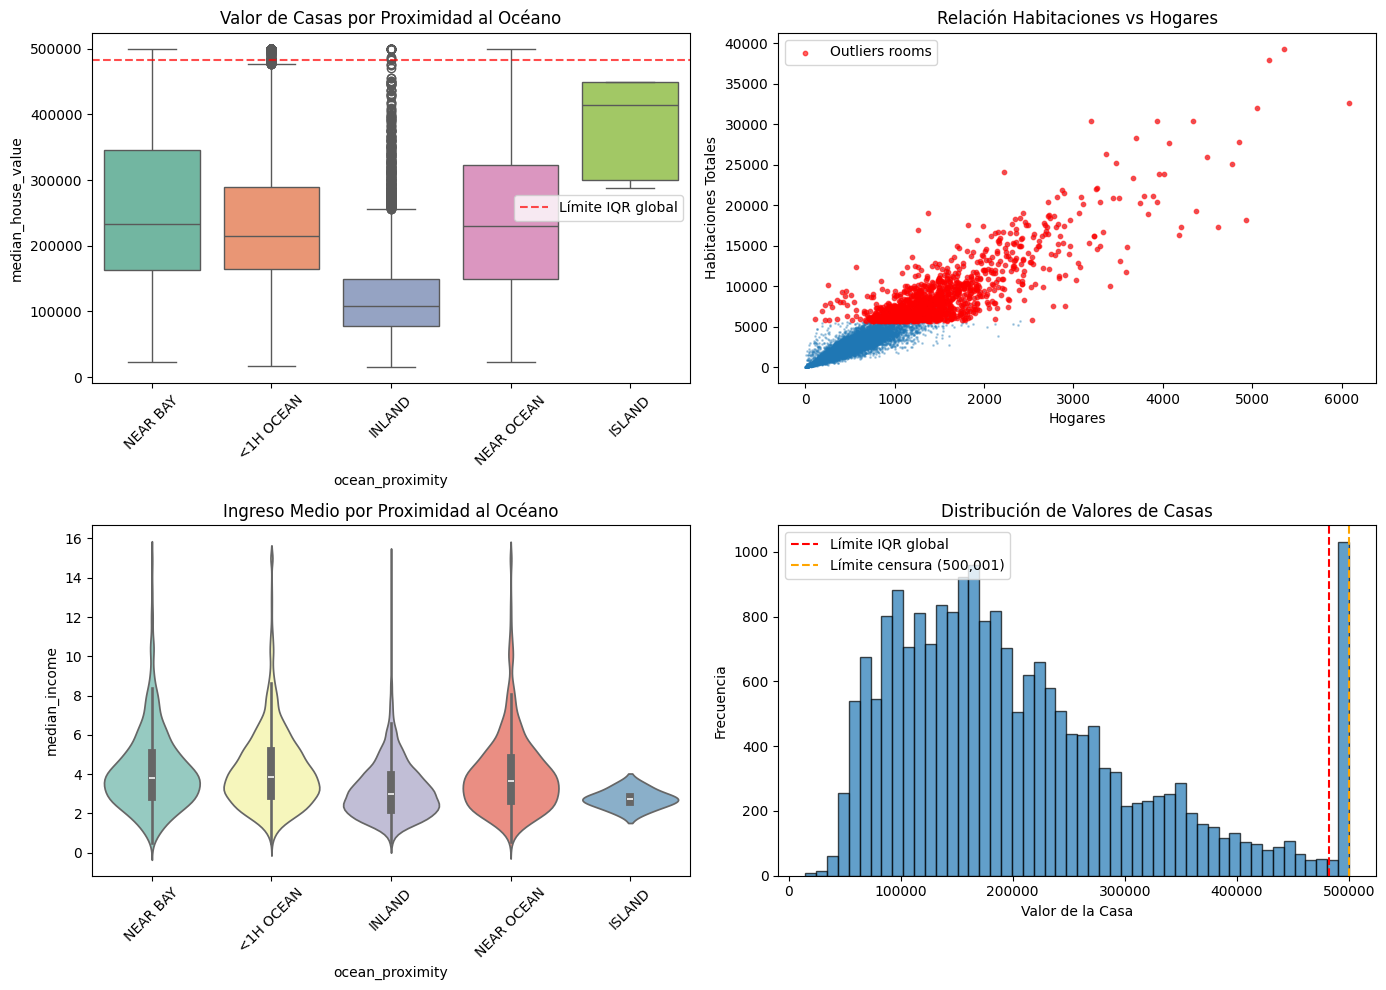


4. REFLEXIÓN: ¿ESTAMOS CAYENDO EN UN SESGO?

SÍ, estamos cayendo en varios sesgos importantes:

1. SESGO GEOGRÁFICO:
   - Un outlier en 'INLAND' (interior) puede ser normal en 'NEAR BAY'
   - Ejemplo: 3000 habitaciones es atípico en zonas rurales pero normal en ciudades costeras
   - Solución: Analizar outliers dentro de cada categoría geográfica

2. SESGO DE CENSURA:
   - median_house_value tiene un límite artificial de 500,001 USD
   - Los "outliers" de 500,001 no son atípicos reales, son datos truncados
   - Solución: Reconocer que el valor real de estas propiedades es ≥500,001

3. SESGO DE ESCALA:
   - Las variables de tamaño (rooms, bedrooms, population) tienen escalas muy diferentes
   - Un complejo de apartamentos legítimo puede tener miles de habitaciones
   - Solución: Normalizar por hogares o población para detectar outliers reales

4. SESGO DE CORRELACIÓN:
   - total_rooms y households están fuertemente correlacionados (r ≈ 0.92)
   - Un outlier en rooms podría no serlo si 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
url = "https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv"
df = pd.read_csv(url)

print("="*80)
print("ANÁLISIS DE OUTLIERS CONTEXTUALIZADO")
print("="*80)

# ==============================================
# 1. ANÁLISIS POR CATEGORÍA GEOGRÁFICA
# ==============================================

print("\n1. OUTLIERS POR PROXIMIDAD AL OCÉANO")
print("-"*80)

variables = ["total_rooms", "total_bedrooms", "population", "median_house_value"]

for var in variables:
    print(f"\n--- {var} ---")

    for category in df['ocean_proximity'].unique():
        datos_cat = df[df['ocean_proximity'] == category][var].dropna()

        if len(datos_cat) > 0:
            Q1 = datos_cat.quantile(0.25)
            Q3 = datos_cat.quantile(0.75)
            IQR = Q3 - Q1
            limite_sup = Q3 + 1.5 * IQR

            outliers = datos_cat[datos_cat > limite_sup]

            print(f"\n  {category}:")
            print(f"    - Total: {len(datos_cat)} bloques")
            print(f"    - Mediana: {datos_cat.median():.0f}")
            print(f"    - Q3: {Q3:.0f}")
            print(f"    - Límite superior: {limite_sup:.0f}")
            print(f"    - Outliers: {len(outliers)} ({len(outliers)/len(datos_cat)*100:.1f}%)")

            if len(outliers) > 0:
                print(f"    - Rango outliers: [{outliers.min():.0f}, {outliers.max():.0f}]")

# ==============================================
# 2. ANÁLISIS DE LA VARIABLE CENSURADA (median_house_value)
# ==============================================

print("\n" + "="*80)
print("2. ANÁLISIS DE LA VARIABLE CENSURADA: median_house_value")
print("="*80)

# Identificar valores censurados (límite superior)
valor_maximo = df['median_house_value'].max()
censurados = df[df['median_house_value'] == valor_maximo]

print(f"\nValor máximo en el dataset: ${valor_maximo:,.0f}")
print(f"Número de propiedades con valor máximo (censuradas): {len(censurados)}")
print(f"Porcentaje del total: {len(censurados)/len(df)*100:.2f}%")

print("\nDistribución de propiedades censuradas por ubicación:")
print(censurados['ocean_proximity'].value_counts())

# ==============================================
# 3. ANÁLISIS DE LA RELACIÓN ENTRE VARIABLES
# ==============================================

print("\n" + "="*80)
print("3. ¿SON REALMENTE OUTLIERS? ANÁLISIS DE CONSISTENCIA")
print("="*80)

# Verificar si las propiedades con muchas habitaciones también tienen muchos hogares
print("\nRelación total_rooms vs households (propiedades extremas):")
limite_rooms = df['total_rooms'].quantile(0.95)
propiedades_extremas = df[df['total_rooms'] > limite_rooms]

print(f"Propiedades con total_rooms > percentil 95 ({limite_rooms:.0f}): {len(propiedades_extremas)}")
print(f"Correlación rooms-households en propiedades extremas: {propiedades_extremas['total_rooms'].corr(propiedades_extremas['households']):.3f}")
print(f"Correlación rooms-households en datos normales: {df[df['total_rooms'] <= limite_rooms]['total_rooms'].corr(df[df['total_rooms'] <= limite_rooms]['households']):.3f}")

# ==============================================
# 4. VISUALIZACIÓN CONTEXTUALIZADA
# ==============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Boxplots por categoría para median_house_value
sns.boxplot(data=df, x='ocean_proximity', y='median_house_value', ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Valor de Casas por Proximidad al Océano')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].axhline(y=482537.5, color='red', linestyle='--', alpha=0.7, label='Límite IQR global')
axes[0,0].legend()

# Gráfico 2: Scatter plot rooms vs households (identificando outliers)
axes[0,1].scatter(df['households'], df['total_rooms'], alpha=0.3, s=1)
axes[0,1].set_xlabel('Hogares')
axes[0,1].set_ylabel('Habitaciones Totales')
axes[0,1].set_title('Relación Habitaciones vs Hogares')
# Marcar outliers de rooms
outliers_rooms = df[df['total_rooms'] > (df['total_rooms'].quantile(0.75) + 1.5*(df['total_rooms'].quantile(0.75)-df['total_rooms'].quantile(0.25)))]
axes[0,1].scatter(outliers_rooms['households'], outliers_rooms['total_rooms'], color='red', s=10, alpha=0.6, label='Outliers rooms')
axes[0,1].legend()

# Gráfico 3: Distribución de median_income por categoría
sns.violinplot(data=df, x='ocean_proximity', y='median_income', ax=axes[1,0], palette='Set3')
axes[1,0].set_title('Ingreso Medio por Proximidad al Océano')
axes[1,0].tick_params(axis='x', rotation=45)

# Gráfico 4: Histograma de median_house_value con límite censurado
axes[1,1].hist(df['median_house_value'], bins=50, alpha=0.7, edgecolor='black')
axes[1,1].axvline(x=482537.5, color='red', linestyle='--', label='Límite IQR global')
axes[1,1].axvline(x=500001, color='orange', linestyle='--', label='Límite censura (500,001)')
axes[1,1].set_xlabel('Valor de la Casa')
axes[1,1].set_ylabel('Frecuencia')
axes[1,1].set_title('Distribución de Valores de Casas')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# ==============================================
# 5. REFLEXIÓN SOBRE EL SESGO
# ==============================================

print("\n" + "="*80)
print("4. REFLEXIÓN: ¿ESTAMOS CAYENDO EN UN SESGO?")
print("="*80)

print("""
SÍ, estamos cayendo en varios sesgos importantes:

1. SESGO GEOGRÁFICO:
   - Un outlier en 'INLAND' (interior) puede ser normal en 'NEAR BAY'
   - Ejemplo: 3000 habitaciones es atípico en zonas rurales pero normal en ciudades costeras
   - Solución: Analizar outliers dentro de cada categoría geográfica

2. SESGO DE CENSURA:
   - median_house_value tiene un límite artificial de 500,001 USD
   - Los "outliers" de 500,001 no son atípicos reales, son datos truncados
   - Solución: Reconocer que el valor real de estas propiedades es ≥500,001

3. SESGO DE ESCALA:
   - Las variables de tamaño (rooms, bedrooms, population) tienen escalas muy diferentes
   - Un complejo de apartamentos legítimo puede tener miles de habitaciones
   - Solución: Normalizar por hogares o población para detectar outliers reales

4. SESGO DE CORRELACIÓN:
   - total_rooms y households están fuertemente correlacionados (r ≈ 0.92)
   - Un outlier en rooms podría no serlo si también tiene muchos hogares
   - Solución: Usar razones (rooms/households) para detectar anomalías

CONCLUSIÓN: Para un análisis robusto, debemos:
- Segmentar por ocean_proximity antes de detectar outliers
- Considerar la censura en median_house_value
- Usar variables normalizadas (ej. rooms_per_household)
- No eliminar outliers automáticamente; investigar su contexto
""")

# ==============================================
# 6. MÉTRICAS CORREGIDAS
# ==============================================

print("\n" + "="*80)
print("5. MÉTRICAS CORREGIDAS: HABITACIONES POR HOGAR")
print("="*80)

# Crear variable normalizada
df['rooms_per_household'] = df['total_rooms'] / df['households']

print("\nEstadísticas de rooms_per_household:")
print(df['rooms_per_household'].describe())

# Detectar outliers en esta variable normalizada
Q1_norm = df['rooms_per_household'].quantile(0.25)
Q3_norm = df['rooms_per_household'].quantile(0.75)
IQR_norm = Q3_norm - Q1_norm
limite_sup_norm = Q3_norm + 1.5 * IQR_norm

outliers_norm = df[df['rooms_per_household'] > limite_sup_norm]
print(f"\nOutliers en rooms_per_household (> {limite_sup_norm:.2f}): {len(outliers_norm)} ({len(outliers_norm)/len(df)*100:.2f}%)")

print("\nComparación:")
print(f"  - Outliers originales en total_rooms: 6.23%")
print(f"  - Outliers corregidos (rooms/household): {len(outliers_norm)/len(df)*100:.2f}%")
print("  → Muchos 'outliers' eran simplemente propiedades grandes con muchos hogares")